# Priceless Bank — Análise Exploratória das 5 Bases

**Mastercard Challenge 2026 · Inteli**

---

## Contexto

O Priceless Bank vem perdendo participação de mercado de forma acelerada. Segundo o benchmarking
apresentado pelo time de Strategy & Transformation, o *market share* por valor transacionado caiu de
**33% no 1T25 para 19% no 4T25** — enquanto LuminaPay subiu de 17% para 30% e Aurora Bank de 6% para 14%.

O objetivo desta análise é **diagnosticar, nos dados, o que está por trás dessa queda** e reunir
evidências que sustentem recomendações estratégicas.

| Concorrente | Perfil | Diferenciais | Share 1T25 → 4T25 |
|---|---|---|---|
| LuminaPay | Nativo digital, jovens adultos | Cashback, sem taxa de cartão, PIX no crédito | 17% → 30% |
| Papaya Bank | Tradicional, meia-idade/idosos | Pontos, financiamentos, adicional sem anuidade | 23% → 28% (2T→4T) |
| Aurora Bank | Nativo digital, alta renda | Produtos exclusivos, Home Broker, investimento vira limite | 6% → 14% |
| Lux Bank | Affluent | Concierge, sala VIP, fidelidade | 8% → 9% |
| **Priceless Bank** | — | — | **33% → 19%** |

## Como este notebook está organizado

1. **Carga e inventário** — o que existe em cada base
2. **Qualidade dos dados** — *leia antes de qualquer conclusão*: duas quebras de regime, um vazio de 7 meses, e o teste que decide o que dá para normalizar (2.6)
3. **Base Clientes** — perfil, renda, cadastro
4. **Base Cartões** — funil emissão → ativação → uso
5. **Base Transacional** — evolução, mix, autorização
6. **Base PIX** — fluxo, contraparte, transferências para si mesmo
7. **Base Investimentos** — semântica do saldo, aportes e resgates
8. **Visão integrada (cliente 360)** — penetração e engajamento
9. **Diagnóstico consolidado** — a deterioração de 2025
10. **Insights e recomendações**
11. **Limitações da análise**

> **Nota metodológica.** Toda conclusão sobre *valores* está restrita a janelas em que a escala dos
> dados é comparável (seções 2.3 e 2.6). A quebra do PIX passou no teste de reescala pura e foi
> **corrigida** (fator 4,13×); a das transações não passou e continua bloqueada. Onde o valor não é utilizável, a
> análise usa **contagens, medianas e participações relativas**, que não são afetadas.

In [1]:
# =============================================================================
# Setup
# =============================================================================
import warnings, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# Os CSVs devem estar na MESMA PASTA deste notebook.
PASTA = Path('.')

# --- Paleta categórica validada (CVD-safe, ordem fixa; nunca cicle as cores) ---
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = C
INK, INK2, INK3 = '#0b0b0b', '#52514e', '#8a8880'
GRID, SURF = '#e6e5e1', '#fcfcfb'

mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': GRID, 'axes.linewidth': 1.0, 'axes.grid': True,
    'axes.grid.axis': 'y', 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.titlepad': 14,
    'axes.labelsize': 9.5, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0,
    'legend.frameon': False, 'legend.fontsize': 9.5,
    'lines.linewidth': 2.0, 'lines.markersize': 5,
    'font.size': 10, 'figure.dpi': 110, 'axes.axisbelow': True,
})

def eixo(ax, titulo=None, sub=None, ylab=None, xlab=None):
    '''Título + subtítulo alinhados à esquerda, com deslocamento em pontos
    (independente da altura do eixo, para nunca colidirem).'''
    if titulo:
        ax.set_title(titulo, pad=28 if sub else 14)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, color=INK2, va='bottom', ha='left')
    ax.set_ylabel(ylab or ''); ax.set_xlabel(xlab or '')
    return ax

def brl(x, pos=None):
    if abs(x) >= 1e6:
        return ('R$ %.1f mi' % (x/1e6)).replace('.', ',')
    return ('R$ %s' % f'{x:,.0f}').replace(',', '.')

def mil(x, pos=None):
    return f'{x:,.0f}'.replace(',', '.')

FMT_BRL, FMT_MIL = FuncFormatter(brl), FuncFormatter(mil)
FMT_PCT = FuncFormatter(lambda v, p: f'{v:.0f}%')

def rot_trim(p):
    '''Period trimestral -> rótulo em português: 2025Q1 -> 1T25.'''
    return f'{p.quarter}T{str(p.year)[2:]}'

def rotula(ax, xs, ys, fmt=lambda v: f'{v:,.0f}', dy=0.02, cor=INK, quais=None):
    '''Rótulo direto seletivo — só nos pontos indicados (nunca em todos).'''
    span = (max(ys) - min(ys)) or 1
    idx = quais if quais is not None else [0, len(xs) - 1]
    for i in idx:
        ax.annotate(fmt(ys[i]), (xs[i], ys[i]), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9, color=cor, fontweight='bold')

print('Ambiente pronto ·', f'pandas {pd.__version__} · matplotlib {mpl.__version__}')

Ambiente pronto · pandas 3.0.2 · matplotlib 3.10.9


---
## 1. Carga e inventário das bases

Cinco arquivos, cinco granularidades diferentes. O primeiro passo é entender **o que é uma linha**
em cada um deles — é isso que define quais joins são válidos.

In [2]:
# =============================================================================
# 1. Carga
# =============================================================================
clientes = pd.read_csv(PASTA / 'Base_clientes_v4.csv')
cartoes  = pd.read_csv(PASTA / 'Base_cartoes_v4.csv')
transac  = pd.read_csv(PASTA / 'Base_transacoes_v4.csv')
pix      = pd.read_csv(PASTA / 'Base_pix_v4.csv')
invest   = pd.read_csv(PASTA / 'Base_investimentos_v4.csv')

BASES = {'Clientes': clientes, 'Cartões': cartoes, 'Transações': transac,
         'PIX': pix, 'Investimentos': invest}

# --- Parsing de datas (formatos diferentes em cada base) ---
clientes['dt_nascimento'] = pd.to_datetime(clientes['Data_Nascimento'], format='%d/%m/%Y', errors='coerce')
clientes['dt_conta']      = pd.to_datetime(clientes['Data_Criacao_Conta'], errors='coerce')

cartoes['dt_emissao']  = pd.to_datetime(cartoes['Data_Emissao'], errors='coerce')
cartoes['dt_ativacao'] = pd.to_datetime(cartoes['Data_Ativacao'], errors='coerce')
cartoes['dt_validade'] = pd.to_datetime(cartoes['Data_Validade'], errors='coerce')

transac['dt'] = pd.to_datetime(transac['Data'], errors='coerce')
pix['dt']     = pd.to_datetime(pix['Data'], errors='coerce')
invest['dt']  = pd.to_datetime(invest['Data'].astype(str), format='%Y%m', errors='coerce')
invest['dt_abertura']   = pd.to_datetime(invest['Data_Abertura_Conta_Inv'].astype(str), format='%Y%m', errors='coerce')
invest['dt_vencimento'] = pd.to_datetime(invest['Data_de_vencimento'].astype(str), format='%Y%m', errors='coerce')

for df, col in [(transac, 'dt'), (pix, 'dt'), (invest, 'dt')]:
    df['ano']      = df[col].dt.year
    df['mes']      = df[col].dt.to_period('M')
    df['trim']     = df[col].dt.to_period('Q')
    df['semestre'] = df[col].dt.year.astype('Int64').astype(str) + 'S' + ((df[col].dt.month > 6).astype('Int64') + 1).astype(str)

print('Bases carregadas.')
for nome, df in BASES.items():
    print(f'  {nome:<14} {df.shape[0]:>7,} linhas × {df.shape[1]:>2} colunas'.replace(',', '.'))

Bases carregadas.
  Clientes         1.960 linhas × 10 colunas
  Cartões          4.006 linhas × 10 colunas
  Transações     156.826 linhas × 19 colunas
  PIX            278.940 linhas × 13 colunas
  Investimentos   21.200 linhas × 14 colunas


In [3]:
# =============================================================================
# 1.1 Inventário: o que é uma linha em cada base?
# =============================================================================
inventario = pd.DataFrame([
    dict(Base='Clientes',      Granularidade='1 linha = 1 cliente',
         Linhas=len(clientes), Chave='Cliente_ID',
         Periodo='cadastro 2023-01 a 2025-12', Clientes=clientes.Cliente_ID.nunique()),
    dict(Base='Cartões',       Granularidade='1 linha = 1 cartão',
         Linhas=len(cartoes),  Chave='ID_Cartao',
         Periodo='emissão 2023-01 a 2025-05', Clientes=np.nan),
    dict(Base='Transações',    Granularidade='1 linha = 1 transação de cartão',
         Linhas=len(transac),  Chave='ID_Transacao',
         Periodo=f'{transac.dt.min():%Y-%m} a {transac.dt.max():%Y-%m}', Clientes=transac.Cliente_ID.nunique()),
    dict(Base='PIX',           Granularidade='1 linha = 1 PIX (sem ID próprio)',
         Linhas=len(pix),      Chave='— (sem chave primária)',
         Periodo=f'{pix.dt.min():%Y-%m} a {pix.dt.max():%Y-%m}', Clientes=pix.Cliente_ID.nunique()),
    dict(Base='Investimentos', Granularidade='1 linha = cliente × produto × mês',
         Linhas=len(invest),   Chave='Cliente_ID + Produto + Data',
         Periodo=f'{invest.dt.min():%Y-%m} a {invest.dt.max():%Y-%m}', Clientes=invest.Cliente_ID.nunique()),
])
display(inventario.style.hide(axis='index').format({'Linhas': '{:,.0f}', 'Clientes': '{:,.0f}'}, na_rep='—'))

print('\nObservação estrutural: a Base de Cartões NÃO possui Cliente_ID.')
print('O vínculo cartão → cliente só existe indiretamente, via Base Transacional.')
print('Consequência: cartões que nunca transacionaram não podem ser atribuídos a nenhum cliente.')

Base,Granularidade,Linhas,Chave,Periodo,Clientes
Clientes,1 linha = 1 cliente,"1,960",Cliente_ID,cadastro 2023-01 a 2025-12,"1,960"
Cartões,1 linha = 1 cartão,"4,006",ID_Cartao,emissão 2023-01 a 2025-05,—
Transações,1 linha = 1 transação de cartão,"156,826",ID_Transacao,2023-01 a 2025-12,"1,431"
PIX,1 linha = 1 PIX (sem ID próprio),"278,940",— (sem chave primária),2023-01 a 2025-12,"1,430"
Investimentos,1 linha = cliente × produto × mês,"21,200",Cliente_ID + Produto + Data,2023-01 a 2025-12,"1,003"



Observação estrutural: a Base de Cartões NÃO possui Cliente_ID.
O vínculo cartão → cliente só existe indiretamente, via Base Transacional.
Consequência: cartões que nunca transacionaram não podem ser atribuídos a nenhum cliente.


---
## 2. Qualidade dos dados

Esta seção vem **antes** de qualquer análise de negócio de propósito. Três achados aqui mudam
completamente a leitura dos números — e ignorá-los levaria a conclusões erradas.

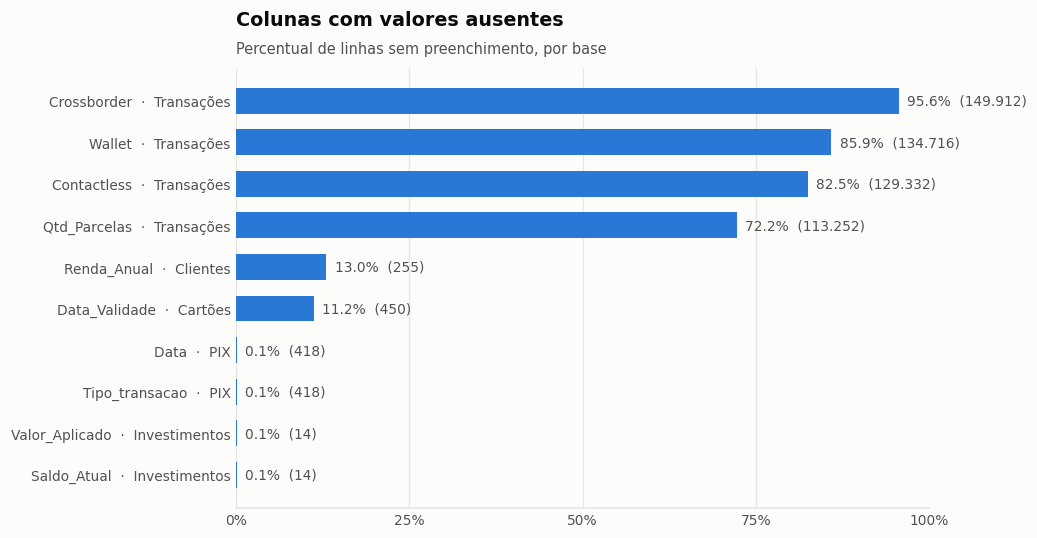

Base,Coluna,Ausentes,Pct
Transações,Crossborder,"149,912",95.6%
Transações,Wallet,"134,716",85.9%
Transações,Contactless,"129,332",82.5%
Transações,Qtd_Parcelas,"113,252",72.2%
Clientes,Renda_Anual,255,13.0%
Cartões,Data_Validade,450,11.2%
PIX,Data,418,0.1%
PIX,Tipo_transacao,418,0.1%
Investimentos,Valor_Aplicado,14,0.1%
Investimentos,Saldo_Atual,14,0.1%


In [4]:
# =============================================================================
# 2.1 Valores ausentes
# =============================================================================
linhas = []
for nome, df in BASES.items():
    n = df.isna().sum()
    for col, q in n[n > 0].items():
        if col.startswith('dt') or col in ('ano','mes','trim','semestre'):
            continue
        linhas.append(dict(Base=nome, Coluna=col, Ausentes=int(q), Pct=100*q/len(df)))
nulos = pd.DataFrame(linhas).sort_values('Pct', ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(nulos))[::-1]
ax.barh(y, nulos.Pct, height=0.62, color=BLUE)
ax.set_yticks(y, [f'{r.Coluna}  ·  {r.Base}' for r in nulos.itertuples()])
for yi, (p, q) in zip(y, zip(nulos.Pct, nulos.Ausentes)):
    ax.text(p + 1.2, yi, f'{p:.1f}%  ({q:,})'.replace(',', '.'), va='center', fontsize=9, color=INK2)
ax.set_xlim(0, 100); ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
eixo(ax, 'Colunas com valores ausentes',
        'Percentual de linhas sem preenchimento, por base')
plt.tight_layout(); plt.show()

display(nulos.style.hide(axis='index').format({'Ausentes': '{:,.0f}', 'Pct': '{:.1f}%'}))

**Como ler cada uma delas — nem todo nulo é um defeito:**

| Coluna | Ausentes | Interpretação |
|---|---|---|
| `Crossborder` (Transações) | 95,6% | Campo praticamente **inutilizável**. Entre os 6.914 preenchidos, a divisão é 50/50 — não há sinal. |
| `Wallet` (Transações) | 85,9% | Nulo = compra **sem carteira digital**. É informação, não defeito: só 14,1% usam wallet. |
| `Contactless` (Transações) | 82,5% | Só 27.494 preenchidos, também 50/50. Inutilizável para medir maturidade digital. |
| `Qtd_Parcelas` (Transações) | 72,2% | Nulo = compra **à vista**. É informação. |
| `Renda_Anual` (Clientes) | 13,0% | **Cadastro incompleto** — e a seção 3.3 mostra que isso tem consequência de negócio. |
| `Data_Validade` (Cartões) | 11,2% | Coincide exatamente com os cartões **nunca ativados** (seção 4). |
| `Data` (PIX) | 0,15% | 418 linhas sem data — fora de qualquer análise temporal. |
| `Tipo_transacao` (PIX) | 0,15% | Outras **418 linhas**, e a interseção com as anteriores é **zero**: são 836 linhas distintas, não as mesmas 418. |
| `Valor_Aplicado` e `Saldo_Atual` (Investimentos) | 0,07% | As **mesmas 14 linhas** — e em todas elas `Data` = `Data_de_vencimento`: são marcações de vencimento sem movimentação. |

> **Implicação para o desafio.** `Crossborder` e `Contactless` são as duas variáveis que naturalmente
> serviriam para medir *maturidade digital* e *internacionalização* — justamente as dimensões do
> benchmarking. Elas **não podem ser usadas**. Qualquer afirmação sobre contactless nesta base seria
> extrapolação de uma amostra de 17% sem garantia de aleatoriedade.

In [5]:
# =============================================================================
# 2.2 Integridade referencial e chaves
# =============================================================================
ids_cli = set(clientes.Cliente_ID)
checks = []

def chk(desc, valor, ok):
    checks.append(dict(Verificação=desc, Resultado=valor, Status='OK' if ok else 'ATENÇÃO'))

chk('Cliente_ID duplicado na base de clientes', clientes.Cliente_ID.duplicated().sum(), clientes.Cliente_ID.duplicated().sum() == 0)
chk('ID_Cartao duplicado na base de cartões',   cartoes.ID_Cartao.duplicated().sum(),   cartoes.ID_Cartao.duplicated().sum() == 0)
chk('ID_Transacao duplicado',                    transac.ID_Transacao.duplicated().sum(), transac.ID_Transacao.duplicated().sum() == 0)
chk('Linhas 100% duplicadas na base PIX',        pix.duplicated().sum(),                  pix.duplicated().sum() == 0)
chk('Chave (Cliente, Produto, Data) duplicada em Investimentos',
    invest.duplicated(['Cliente_ID','Produto_Investimento','Data']).sum(),
    invest.duplicated(['Cliente_ID','Produto_Investimento','Data']).sum() == 0)

for nome, s in [('Transações', transac.Cliente_ID), ('PIX', pix.Cliente_ID), ('Investimentos', invest.Cliente_ID)]:
    orf = len(set(s.dropna().unique()) - ids_cli)
    chk(f'Cliente_ID órfão em {nome} (não existe no cadastro)', orf, orf == 0)

orf_card = len(set(transac.ID_Cartao) - set(cartoes.ID_Cartao))
chk('ID_Cartao em Transações ausente da base de Cartões', orf_card, orf_card == 0)
chk('Cartão compartilhado por mais de um cliente', int((transac.groupby('ID_Cartao').Cliente_ID.nunique() > 1).sum()), True)

display(pd.DataFrame(checks).style.hide(axis='index')
        .map(lambda v: f'color: {GREEN}; font-weight: bold' if v == 'OK' else
                       (f'color: {ORANGE}; font-weight: bold' if v == 'ATENÇÃO' else ''), subset=['Status']))

print('\n— Cobertura de clientes —')
cob = pd.DataFrame({
    'Clientes': [clientes.Cliente_ID.nunique(), transac.Cliente_ID.nunique(),
                 pix.Cliente_ID.nunique(), invest.Cliente_ID.nunique()],
}, index=['Cadastro', 'Com transação de cartão', 'Com PIX', 'Com investimento'])
cob['% do cadastro'] = (100 * cob.Clientes / clientes.Cliente_ID.nunique()).round(1)
display(cob)

sem_nada = ids_cli - set(transac.Cliente_ID) - set(pix.Cliente_ID) - set(invest.Cliente_ID)
print(f'\nClientes no cadastro sem NENHUMA movimentação em 3 anos: {len(sem_nada)} '
      f'({100*len(sem_nada)/len(clientes):.1f}% da base)')

decl, real = int(clientes.Numero_Cartoes.sum()), len(cartoes)
print(f'Cartões declarados no cadastro: {decl:,} | Cartões na base de cartões: {real:,} | Diferença: {decl-real:,}'.replace(',', '.'))

Verificação,Resultado,Status
Cliente_ID duplicado na base de clientes,0,OK
ID_Cartao duplicado na base de cartões,0,OK
ID_Transacao duplicado,0,OK
Linhas 100% duplicadas na base PIX,0,OK
"Chave (Cliente, Produto, Data) duplicada em Investimentos",0,OK
Cliente_ID órfão em Transações (não existe no cadastro),0,OK
Cliente_ID órfão em PIX (não existe no cadastro),0,OK
Cliente_ID órfão em Investimentos (não existe no cadastro),0,OK
ID_Cartao em Transações ausente da base de Cartões,0,OK
Cartão compartilhado por mais de um cliente,0,OK



— Cobertura de clientes —


,Clientes,% do cadastro
Cadastro,1960,100.00
Com transação de cartão,1431,73.00
Com PIX,1430,73.00
Com investimento,1003,51.20



Clientes no cadastro sem NENHUMA movimentação em 3 anos: 85 (4.3% da base)
Cartões declarados no cadastro: 4.931 | Cartões na base de cartões: 4.006 | Diferença: 925


### 2.3 Achado crítico — duas quebras de escala nos valores monetários

Antes de comparar receita ou volume financeiro entre períodos, é preciso verificar se a **escala dos
valores** é comparável. A mediana é o teste certo: ela é insensível a outliers, então um salto brusco
na mediana indica mudança no processo gerador dos dados, não mudança de comportamento do cliente.

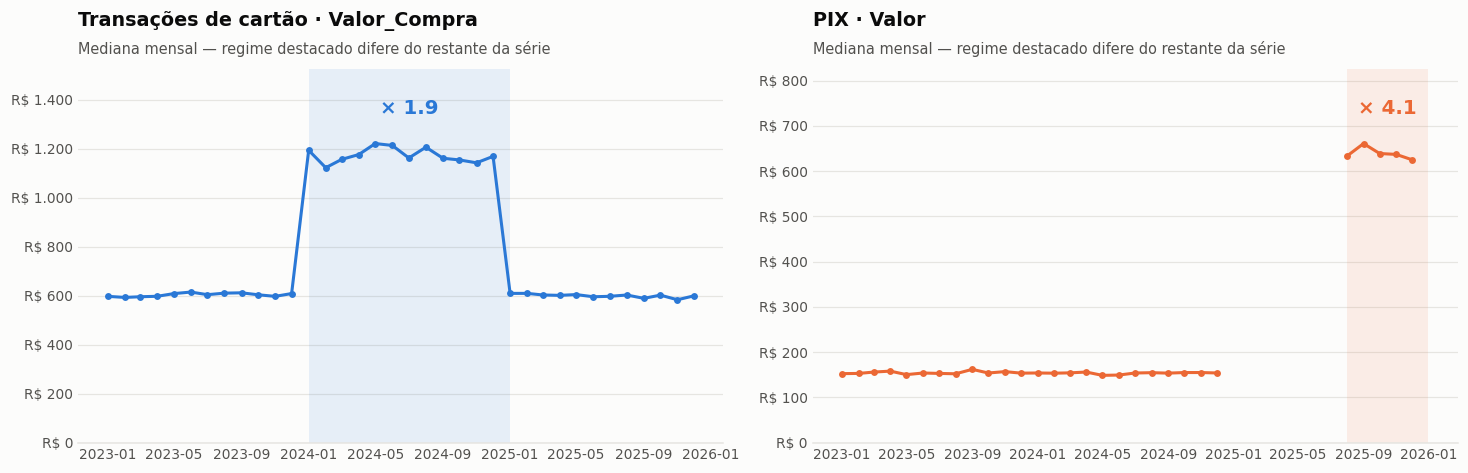

Base,Regime,Mediana
Transações,2023 e 2025,R$ 602.88
Transações,2024,"R$ 1,166.15"
PIX,2023-01 a 2024-12,R$ 153.92
PIX,2025-08 a 2025-12,R$ 637.05


In [6]:
# =============================================================================
# 2.3 Detecção de quebras de escala (mediana mensal)
# =============================================================================
meses_todos = pd.period_range('2023-01', '2025-12', freq='M')
# Reindexar para a série completa: os meses ausentes viram NaN e a linha QUEBRA no gráfico,
# em vez de desenhar uma rampa falsa por cima do vazio de 2025 (ver 2.4).
med_tx  = (transac[transac.Autorizado == 'Sim'].groupby('mes').Valor_Compra.median()
           .reindex(meses_todos))
med_pix = (pix[(pix.Aprovado == 1) & (pix.Valor >= 0)].groupby('mes').Valor.median()
           .reindex(meses_todos))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

for ax, s, nome, cor, quebra in [
        (axes[0], med_tx,  'Transações de cartão · Valor_Compra', BLUE,   ('2024-01', '2024-12')),
        (axes[1], med_pix, 'PIX · Valor',                          ORANGE, ('2025-08', '2025-12'))]:
    x = s.index.to_timestamp()
    ax.plot(x, s.values, color=cor, marker='o', markersize=3.5)
    ini, fim = pd.Timestamp(quebra[0]), pd.Timestamp(quebra[1]) + pd.offsets.MonthEnd(0)
    ax.axvspan(ini, fim, color=cor, alpha=0.10, lw=0)
    ax.yaxis.set_major_formatter(FMT_BRL)
    dentro = s[(s.index.to_timestamp() >= ini) & (s.index.to_timestamp() <= fim)].median()
    fora   = s[(s.index.to_timestamp() <  ini) | (s.index.to_timestamp() >  fim)].median()
    ax.set_ylim(0, np.nanmax(s.values) * 1.25)
    ax.annotate(f'× {dentro/fora:.1f}', ((ini + (fim - ini)/2), np.nanmax(s.values)*1.10),
                ha='center', fontsize=13, fontweight='bold', color=cor)
    eixo(ax, nome, 'Mediana mensal — regime destacado difere do restante da série')

plt.tight_layout(); plt.show()

resumo_escala = pd.DataFrame([
    dict(Base='Transações', Regime='2023 e 2025', Mediana=med_tx[med_tx.index.year != 2024].median()),
    dict(Base='Transações', Regime='2024',        Mediana=med_tx[med_tx.index.year == 2024].median()),
    dict(Base='PIX',        Regime='2023-01 a 2024-12', Mediana=med_pix[med_pix.index < pd.Period('2025-01')].median()),
    dict(Base='PIX',        Regime='2025-08 a 2025-12', Mediana=med_pix[med_pix.index >= pd.Period('2025-08')].median()),
])
display(resumo_escala.style.hide(axis='index').format({'Mediana': 'R$ {:,.2f}'}))

**O que isso significa.** Não é sazonalidade nem mudança de comportamento — a distribuição inteira se
desloca de um mês para o outro e volta depois:

- **Transações:** em 2023 e 2025 a mediana fica estável em ~R$ 600 e a distribuição é quase simétrica
  (média ≈ mediana ≈ 605). Em 2024 a mediana salta para ~R$ 1.170 e a distribuição fica assimétrica
  (média 1.550, p95 R$ 4.250 contra R$ 1.140 nos outros anos). É **outro processo gerador**.
- **PIX:** de 2025-08 em diante a mediana do envio passa de R$ 154 para R$ 636 (×4,1) e 14,5% dos envios
  superam R$ 2.000 — algo que **nunca ocorreu** nos 4 semestres anteriores (0,0%).

**Regra adotada neste notebook**

| Tipo de métrica | Uso |
|---|---|
| Valores em R$ comparados **entre** regimes | ❌ Não usar. Produziria um falso crescimento de +156% em 2024 e um falso "vazamento de caixa" em 2025S2. |
| Valores em R$ **dentro** de um mesmo regime | ✅ Válido |
| Contagens, nº de clientes, frequência, participações (%) | ✅ Válido em toda a série — não são afetadas por escala |
| Base de Investimentos | ✅ Sem quebra: mediana do aporte estável entre R$ 1.569 e R$ 2.237 nos 12 trimestres |

Essa é a regra **provisória**. A seção 2.6 testa formalmente se cada quebra pode ser corrigida — e
descobre que uma pode e a outra não, o que libera parte das análises de valor.

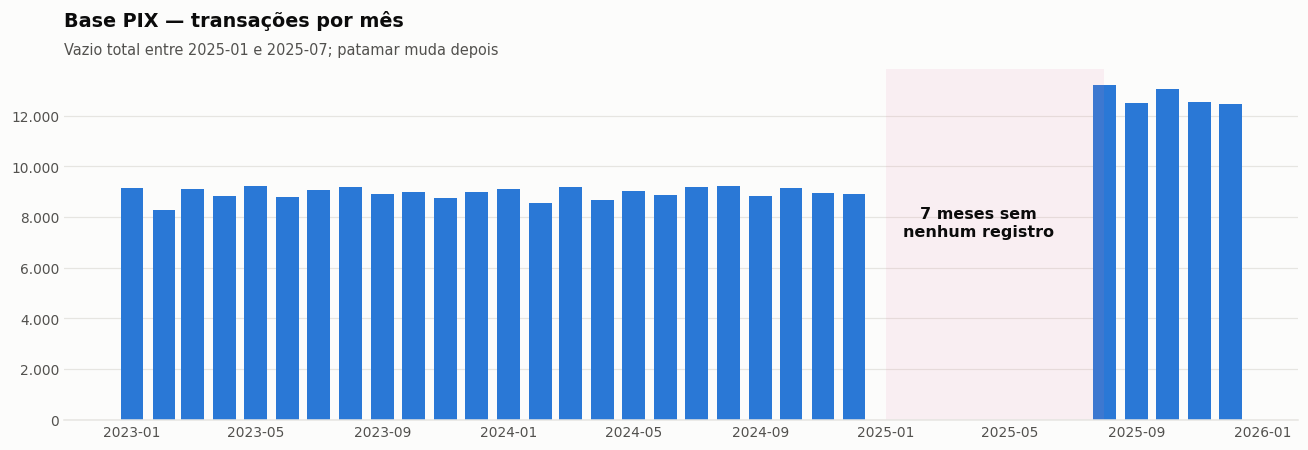

Meses ausentes: 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07

Média mensal 2023-2024: 8.951 PIX
Média mensal 2025-08+ : 12.741 PIX


In [7]:
# =============================================================================
# 2.4 Achado crítico — 7 meses ausentes na base PIX
# =============================================================================
cont = pix.dropna(subset=['dt']).groupby('mes').size()
idx  = pd.period_range(cont.index.min(), cont.index.max(), freq='M')
cont = cont.reindex(idx, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4.2))
x = cont.index.to_timestamp()
cores = [MAGENTA if v == 0 else BLUE for v in cont.values]
ax.bar(x, cont.values, width=22, color=cores)
falta = cont[cont == 0]
ax.axvspan(falta.index.min().to_timestamp(), falta.index.max().to_timestamp() + pd.offsets.MonthEnd(0),
           color=MAGENTA, alpha=0.10, lw=0)
ax.annotate(f'{len(falta)} meses sem\nnenhum registro',
            (falta.index[len(falta)//2].to_timestamp(), cont.max()*0.55),
            ha='center', fontsize=10.5, fontweight='bold', color=INK)
ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Base PIX — transações por mês', 'Vazio total entre 2025-01 e 2025-07; patamar muda depois')
plt.tight_layout(); plt.show()

print('Meses ausentes:', ', '.join(str(p) for p in falta.index))
print(f'\nMédia mensal 2023-2024: {cont[cont.index < pd.Period("2025-01")].mean():,.0f} PIX'.replace(',', '.'))
print(f'Média mensal 2025-08+ : {cont[cont.index >= pd.Period("2025-08")].mean():,.0f} PIX'.replace(',', '.'))

> **Consequência direta.** Qualquer análise de PIX ao longo de 2025 está comprometida. É impossível
> distinguir "os clientes pararam de usar PIX" de "os dados não foram extraídos". Por isso, **o PIX não
> é usado como evidência da queda de 2025** neste notebook — só as bases de Transações e Investimentos,
> que têm série completa.
>
> Para o desafio, vale registrar o ponto: a maior base do banco (279 mil linhas) tem 7 meses faltando e
> nenhuma chave primária. Isso é, por si só, um achado sobre a **maturidade de dados** do Priceless Bank.

In [8]:
# =============================================================================
# 2.5 Demais inconsistências encontradas
# =============================================================================
nao_ativados = cartoes.dt_ativacao.dt.year <= 1900
achados = pd.DataFrame([
    dict(Base='Cartões', Achado='Data_Ativacao = 1900-01-01 (sentinela para "nunca ativado")',
         Qtd=int(nao_ativados.sum()), Tratamento='Reclassificado como cartão não ativado'),
    dict(Base='Cartões', Achado='Sem Cliente_ID — cartão só se liga ao cliente via Transações',
         Qtd=len(cartoes), Tratamento='469 cartões ficam sem dono identificável'),
    dict(Base='Cartões', Achado='Limite_Cartao = 0',
         Qtd=int((cartoes.Limite_Cartao == 0).sum()), Tratamento='São 100% cartões de débito — correto'),
    dict(Base='Transações', Achado='Valor_Compra negativo (estorno/chargeback)',
         Qtd=int((transac.Valor_Compra < 0).sum()), Tratamento='Mantidos; somam R$ -132 mil'),
    dict(Base='PIX', Achado='Valor negativo, chegando a R$ -585.848',
         Qtd=int((pix.Valor < 0).sum()), Tratamento='Excluídos das análises de valor (outliers inconsistentes)'),
    dict(Base='PIX', Achado='Sem chave primária — não há ID de transação',
         Qtd=len(pix), Tratamento='Impossível auditar duplicidade lógica'),
    dict(Base='Investimentos', Achado='Data_de_vencimento anterior à data da operação',
         Qtd=int(((invest.Data_de_vencimento < invest.Data) & (invest.Data_de_vencimento != 299901)).sum()),
         Tratamento='Sinalizado; não impacta as métricas usadas'),
    dict(Base='Investimentos', Achado='Data_de_vencimento = 299901 (produto sem vencimento)',
         Qtd=int((invest.Data_de_vencimento == 299901).sum()), Tratamento='100% Reservinha — sentinela correta'),
    dict(Base='Clientes', Achado='Clientes sem nenhuma movimentação em 3 anos',
         Qtd=len(sem_nada), Tratamento='Mantidos; analisados na seção 8'),
])
display(achados.style.hide(axis='index').format({'Qtd': '{:,.0f}'}))

Base,Achado,Qtd,Tratamento
Cartões,"Data_Ativacao = 1900-01-01 (sentinela para ""nunca ativado"")",450,Reclassificado como cartão não ativado
Cartões,Sem Cliente_ID — cartão só se liga ao cliente via Transações,"4,006",469 cartões ficam sem dono identificável
Cartões,Limite_Cartao = 0,606,São 100% cartões de débito — correto
Transações,Valor_Compra negativo (estorno/chargeback),165,Mantidos; somam R$ -132 mil
PIX,"Valor negativo, chegando a R$ -585.848",917,Excluídos das análises de valor (outliers inconsistentes)
PIX,Sem chave primária — não há ID de transação,"278,940",Impossível auditar duplicidade lógica
Investimentos,Data_de_vencimento anterior à data da operação,188,Sinalizado; não impacta as métricas usadas
Investimentos,Data_de_vencimento = 299901 (produto sem vencimento),"7,864",100% Reservinha — sentinela correta
Clientes,Clientes sem nenhuma movimentação em 3 anos,85,Mantidos; analisados na seção 8


### 2.6 Dá para normalizar? — teste formal e correção

Normalizar significa multiplicar os valores de um regime por um fator para trazê-los à mesma escala do
outro. **Isso só é válido se a quebra for uma reescala pura** — ou seja, se *todos* os valores tiverem
sido multiplicados pelo mesmo número.

O teste é direto: se for escala pura, a razão entre os quantis dos dois regimes é **constante**. Se a
razão varia ao longo da distribuição, o que mudou não foi a escala — foi a própria forma da
distribuição, e nenhum fator único conserta isso.

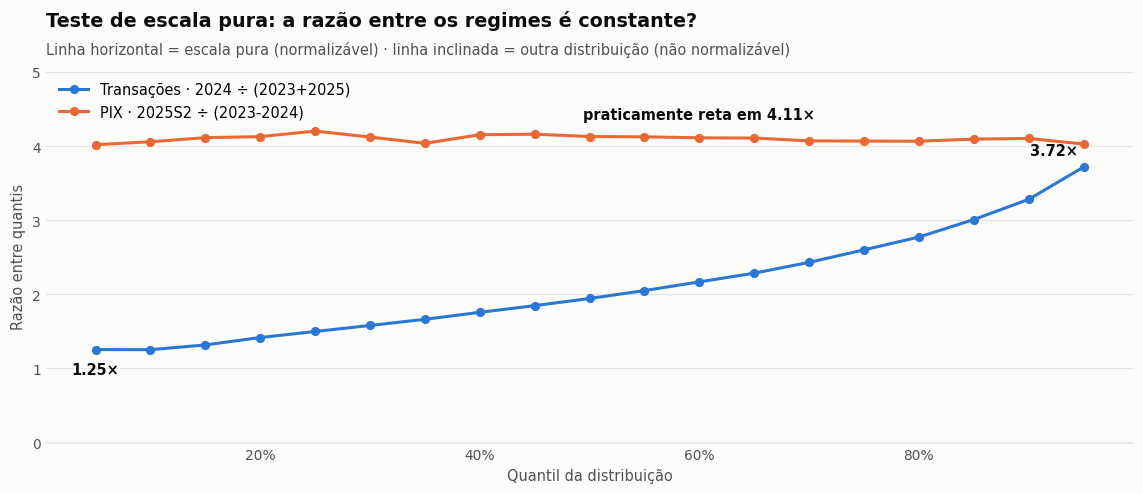

Quebra,Razao_min,Razao_max,Desvio,Skew_ref,Skew_alvo,CV_ref,CV_alvo
Transações · 2024,1.253,3.717,0.697,17.729,15.527,0.835,1.068
PIX · 2025S2,4.018,4.202,0.046,1.794,1.823,1.108,1.107


In [9]:
# =============================================================================
# 2.6.1 Teste de escala pura: razão entre quantis
# =============================================================================
QS = np.arange(0.05, 1.00, 0.05)

t_ok  = transac[(transac.Autorizado == 'Sim') & (transac.Valor_Compra > 0)]
tx_ref, tx_alv = t_ok[t_ok.ano != 2024].Valor_Compra, t_ok[t_ok.ano == 2024].Valor_Compra

p_ok = pix[(pix.Aprovado == 1) & (pix.Valor > 0) & pix.dt.notna()]
px_ref = p_ok[p_ok.dt <  '2025-01-01'].Valor
px_alv = p_ok[p_ok.dt >= '2025-08-01'].Valor

razao_tx = tx_alv.quantile(QS).values / tx_ref.quantile(QS).values
razao_px = px_alv.quantile(QS).values / px_ref.quantile(QS).values

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(QS*100, razao_tx, color=BLUE,   marker='o', label='Transações · 2024 ÷ (2023+2025)')
ax.plot(QS*100, razao_px, color=ORANGE, marker='o', label='PIX · 2025S2 ÷ (2023-2024)')
ax.annotate(f'{razao_tx[0]:.2f}×', (QS[0]*100, razao_tx[0]), xytext=(0, -16), textcoords='offset points',
            ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.annotate(f'{razao_tx[-1]:.2f}×', (QS[-1]*100, razao_tx[-1]), xytext=(-4, 8), textcoords='offset points',
            ha='right', fontsize=9.5, fontweight='bold', color=INK)
ax.annotate(f'praticamente reta em {np.median(razao_px):.2f}×',
            (60, razao_px[11]), xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, max(razao_tx.max(), razao_px.max())*1.20)
ax.xaxis.set_major_formatter(FMT_PCT); ax.legend(loc='upper left')
eixo(ax, 'Teste de escala pura: a razão entre os regimes é constante?',
        'Linha horizontal = escala pura (normalizável) · linha inclinada = outra distribuição (não normalizável)',
        ylab='Razão entre quantis', xlab='Quantil da distribuição')
plt.tight_layout(); plt.show()

diag = pd.DataFrame([
    dict(Quebra='Transações · 2024', Razao_min=razao_tx.min(), Razao_max=razao_tx.max(),
         Desvio=razao_tx.std(), Skew_ref=tx_ref.skew(), Skew_alvo=tx_alv.skew(),
         CV_ref=tx_ref.std()/tx_ref.mean(), CV_alvo=tx_alv.std()/tx_alv.mean()),
    dict(Quebra='PIX · 2025S2', Razao_min=razao_px.min(), Razao_max=razao_px.max(),
         Desvio=razao_px.std(), Skew_ref=px_ref.skew(), Skew_alvo=px_alv.skew(),
         CV_ref=px_ref.std()/px_ref.mean(), CV_alvo=px_alv.std()/px_alv.mean()),
])
display(diag.style.hide(axis='index').format({c: '{:.3f}' for c in diag.columns if c != 'Quebra'}))

**Veredito: uma normaliza, a outra não.**

| | Transações (2024) | PIX (2025S2) |
|---|---|---|
| Razão no p5 | 1,25× | 4,02× |
| Razão no p95 | 3,72× | 4,03× |
| Desvio-padrão das razões | **0,70** | **0,05** |
| Coeficiente de variação (antes → depois) | 0,835 → 1,068 | 1,108 → **1,107** |
| Assimetria (antes → depois) | 17,7 → 15,5 | 1,794 → **1,823** |
| **Normalizável?** | **Não** | **Sim** |

No PIX, a razão é uma **reta em 4,13×** do p5 ao p95 (mínimo 4,02, máximo 4,20), e a forma da distribuição fica intacta até a
terceira casa decimal (CV 1,108 → 1,107). É a assinatura inequívoca de uma reescala: alguém multiplicou
a coluna inteira por uma constante.

Nas transações, a razão vai de **1,25× nas compras pequenas a 3,72× nas grandes**. Não houve
multiplicação — as compras baratas quase não mudaram e as caras explodiram. Dividir tudo por um número
só não recupera nada; apenas troca um erro por outro.

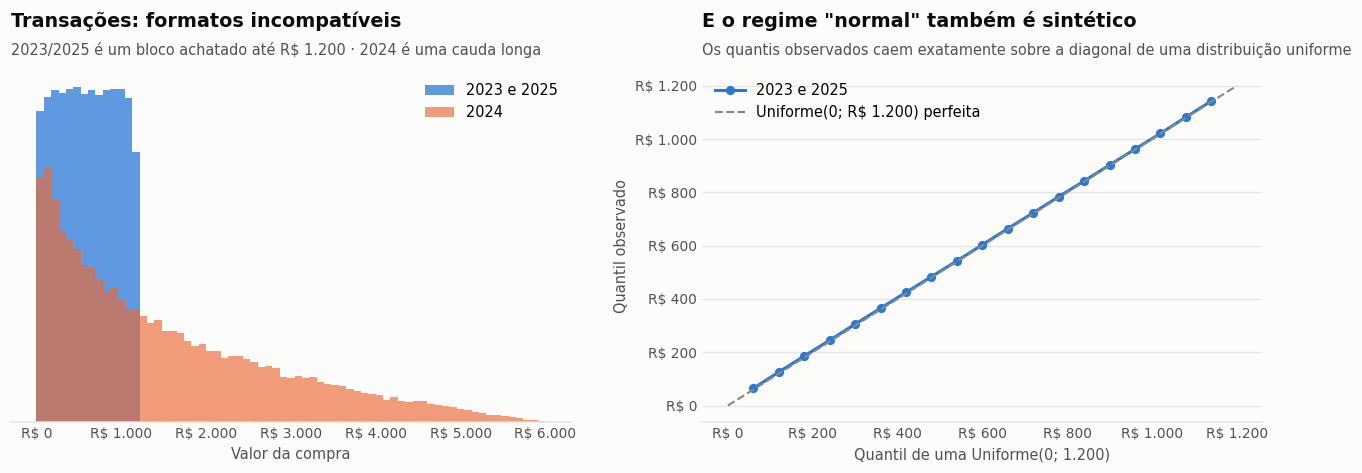

Compras acima de R$ 1.200 — 2023 e 2025: 0.09%   |   2024: 49.3%
Mediana 2023+2025: R$ 603  (Uniforme(0;1.200) teria R$ 600)
Assimetria (aparada no p99) — 2023+2025: -0.00 (uma uniforme teria 0)   |   2024: 0.89 (cauda à direita)


In [10]:
# =============================================================================
# 2.6.2 Por que as transações não normalizam: são duas distribuições diferentes
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
bins = np.linspace(0, 6000, 70)
ax.hist(tx_ref, bins=bins, color=BLUE,   alpha=.75, label='2023 e 2025', density=True)
ax.hist(tx_alv, bins=bins, color=ORANGE, alpha=.65, label='2024',        density=True)
ax.legend(loc='upper right'); ax.set_yticks([])
ax.xaxis.set_major_formatter(FMT_BRL); ax.grid(axis='y', visible=False)
eixo(ax, 'Transações: formatos incompatíveis',
        '2023/2025 é um bloco achatado até R$ 1.200 · 2024 é uma cauda longa', xlab='Valor da compra')

ax = axes[1]
teorico = 1200 * QS
ax.plot(teorico, tx_ref.quantile(QS).values, color=BLUE, marker='o', label='2023 e 2025')
ax.plot([0, 1200], [0, 1200], color=INK3, ls='--', lw=1.4, label='Uniforme(0; R$ 1.200) perfeita')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(FMT_BRL); ax.yaxis.set_major_formatter(FMT_BRL)
eixo(ax, 'E o regime "normal" também é sintético',
        'Os quantis observados caem exatamente sobre a diagonal de uma distribuição uniforme',
        xlab='Quantil de uma Uniforme(0; 1.200)', ylab='Quantil observado')

plt.tight_layout(); plt.show()

print(f'Compras acima de R$ 1.200 — 2023 e 2025: {100*(tx_ref>1200).mean():.2f}%   |   2024: {100*(tx_alv>1200).mean():.1f}%')
print(f'Mediana 2023+2025: R$ {tx_ref.median():,.0f}  (Uniforme(0;1.200) teria R$ 600)'.replace(',', '.'))
print(f'Assimetria (aparada no p99) — 2023+2025: {tx_ref[tx_ref <= tx_ref.quantile(.99)].skew():.2f} '
      f'(uma uniforme teria 0)   |   2024: {tx_alv[tx_alv <= tx_alv.quantile(.99)].skew():.2f} (cauda à direita)')

**Achado adicional, e talvez o mais importante para o critério "qualidade e acurácia dos dados".**

O regime "normal" das transações — 2023 e 2025, dois terços da base — é uma **distribuição uniforme
entre R$ 0 e R$ 1.200**. Os quantis observados caem praticamente em cima da diagonal teórica: p25 =
R$ 305 (uniforme: R$ 300), p50 = R$ 603 (R$ 600), p75 = R$ 903 (R$ 900), p90 = R$ 1.082 (R$ 1.080).
Apenas 0,09% das compras passam de R$ 1.200.

Consumo real nunca tem esse formato: gasto de cartão é fortemente assimétrico, com muitas compras
pequenas e poucas grandes. Uma reta perfeita significa que a coluna `Valor_Compra` foi **gerada por
sorteio**, não observada.

**A consequência prática é grande:** o valor da transação **não carrega informação** nesta base. Ticket
médio, "clientes de alto valor", gasto por faixa de renda — nada disso tem significado, porque o valor
foi sorteado independentemente do cliente. Isso explica por que a correlação entre renda anual e gasto
em 2025 é de -0,05 (seção 11).

É por isso que todo o diagnóstico deste notebook foi construído sobre **contagens, frequência e
participações** — que refletem o comportamento — e não sobre reais.

In [11]:
# =============================================================================
# 2.6.3 Aplicando a normalização onde ela é válida
# =============================================================================
# --- PIX: reescala pura, corrigível ---
K_PIX = px_alv.median() / px_ref.median()
pix['Valor_norm'] = np.where(pix.dt >= '2025-08-01', pix.Valor / K_PIX, pix.Valor)
print(f'PIX · fator de normalização estimado (razão das medianas): K = {K_PIX:.4f}')
print(f'      (mediana das razões p5..p95: {np.median(razao_px):.4f} — estimativas convergem)\n')

pn = pix[(pix.Aprovado == 1) & pix.dt.notna() & pix.Valor.between(0, 1e5)].copy()
pn['sem'] = pn.dt.dt.year.astype(str) + 'S' + ((pn.dt.dt.month > 6).astype(int) + 1).astype(str)
env = pn[pn.Tipo_transacao == 'Envio']
check = env.groupby('sem').Valor_norm.agg(Envios='size', Mediana='median', Media='mean')
print('Validação — o ticket do PIX deve ficar constante após a correção:')
display(check.round(1))

# --- Transações: normalização inválida. Proxy honesto de volume ---
TICKET_REF = tx_ref.median()
vol = (transac[transac.Autorizado == 'Sim'].groupby('trim').size() * TICKET_REF)
print(f'\nTransações · normalização por fator: INVÁLIDA (ver 2.6.1).')
print(f'  Alternativa adotada: "volume ajustado" = nº de transações × ticket de referência '
      f'(R$ {TICKET_REF:,.0f}).'.replace(',', '.'))
print(f'  É a contagem vestida de reais — comparável entre períodos, e explicitamente um proxy.')
transac_volume_ajustado = vol
display(vol.rename('Volume ajustado (R$)').to_frame().T.style.format('R$ {:,.0f}'))

PIX · fator de normalização estimado (razão das medianas): K = 4.1286
      (mediana das razões p5..p95: 4.1082 — estimativas convergem)



Validação — o ticket do PIX deve ficar constante após a correção:


,Envios,Mediana,Media
sem,,,
2023S1,42161,153.60,254.10
2023S2,42489,155.00,254.10
2024S1,42018,152.90,252.10
2024S2,42621,153.60,254.00
2025S2,50996,154.10,251.60



Transações · normalização por fator: INVÁLIDA (ver 2.6.1).
  Alternativa adotada: "volume ajustado" = nº de transações × ticket de referência (R$ 603).
  É a contagem vestida de reais — comparável entre períodos, e explicitamente um proxy.


trim,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
Volume ajustado (R$),"R$ 7,348,681","R$ 6,476,855","R$ 6,968,577","R$ 7,155,612","R$ 6,399,627","R$ 6,562,529","R$ 7,910,391","R$ 9,079,060","R$ 11,497,247","R$ 11,235,397","R$ 7,686,552","R$ 5,792,667"


**O que ficou disponível depois desta seção:**

| Métrica | Antes | Depois |
|---|---|---|
| Valor do PIX ao longo da série | ❌ incomparável | ✅ `Valor_norm`, comparável em 2023-2025 |
| Fluxo líquido de PIX em R$ | ❌ | ✅ (seção 6.3) |
| Valor do PIX na tabela cliente 360 | ❌ | ✅ |
| Valor da transação entre anos | ❌ | ❌ — segue inválido, e agora sabemos por quê |
| Volume de cartão em R$ | ❌ | ⚠️ proxy declarado (contagem × ticket de referência) |

**Uma ressalva que precisa ser dita em voz alta.** Estatisticamente, "alguém multiplicou a coluna por
4,1" e "todos os clientes passaram a mandar PIX 4,1 vezes maiores" são indistinguíveis — as duas coisas
preservam forma, CV e assimetria. O que decide a favor da primeira leitura é o contexto: a mudança é
instantânea, atinge todo mundo igualmente, e acontece exatamente no mês em que a extração da base volta
depois de sete meses de vazio. **Ao normalizar, estamos assumindo que a escala mudou e o comportamento
de valor não.** Sob essa premissa, o que sobra de sinal é a **quantidade** de PIX — e é aí que a
seção 6.3 mostra que algo de fato mudou.

---
## 3. Base Clientes

1.960 clientes, cadastrados entre janeiro de 2023 e dezembro de 2025.

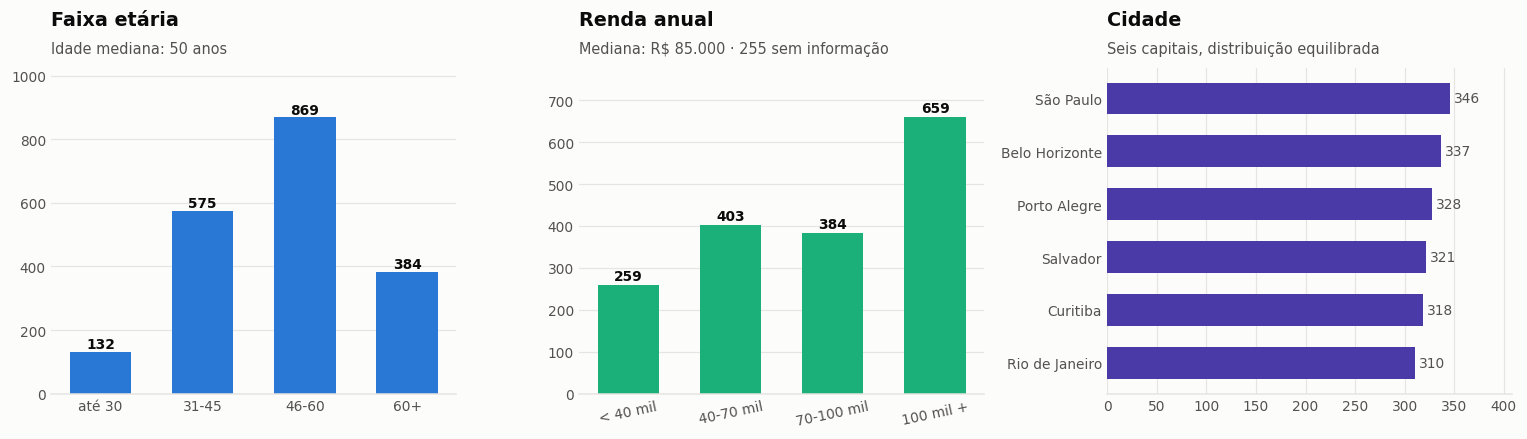

In [12]:
# =============================================================================
# 3.1 Perfil demográfico
# =============================================================================
REF = pd.Timestamp('2025-12-31')
clientes['idade'] = ((REF - clientes.dt_nascimento).dt.days / 365.25).round(0)
clientes['faixa_etaria'] = pd.cut(clientes.idade, [0, 30, 45, 60, 200],
                                  labels=['até 30', '31-45', '46-60', '60+'])
clientes['faixa_renda'] = pd.cut(clientes.Renda_Anual, [0, 40_000, 70_000, 100_000, np.inf],
                                 labels=['< 40 mil', '40-70 mil', '70-100 mil', '100 mil +'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))

ax = axes[0]
fe = clientes.faixa_etaria.value_counts().reindex(['até 30','31-45','46-60','60+'])
ax.bar(range(len(fe)), fe.values, width=0.6, color=BLUE)
ax.set_xticks(range(len(fe)), fe.index)
for i, v in enumerate(fe.values):
    ax.text(i, v + 12, f'{v}', ha='center', fontsize=9, color=INK, fontweight='bold')
ax.set_ylim(0, fe.max()*1.18)
eixo(ax, 'Faixa etária', f'Idade mediana: {clientes.idade.median():.0f} anos')

ax = axes[1]
fr = clientes.faixa_renda.value_counts().reindex(['< 40 mil','40-70 mil','70-100 mil','100 mil +'])
ax.bar(range(len(fr)), fr.values, width=0.6, color=AQUA)
ax.set_xticks(range(len(fr)), fr.index, rotation=12)
for i, v in enumerate(fr.values):
    ax.text(i, v + 12, f'{v}', ha='center', fontsize=9, color=INK, fontweight='bold')
ax.set_ylim(0, fr.max()*1.18)
eixo(ax, 'Renda anual', f'Mediana: {brl(clientes.Renda_Anual.median())} · 255 sem informação')

ax = axes[2]
ci = clientes.Cidade.value_counts()
ax.barh(range(len(ci))[::-1], ci.values, height=0.6, color=VIOLET)
ax.set_yticks(range(len(ci))[::-1], ci.index)
for i, v in zip(range(len(ci))[::-1], ci.values):
    ax.text(v + 4, i, f'{v}', va='center', fontsize=9, color=INK2)
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, ci.max()*1.18)
eixo(ax, 'Cidade', 'Seis capitais, distribuição equilibrada')

plt.tight_layout(); plt.show()

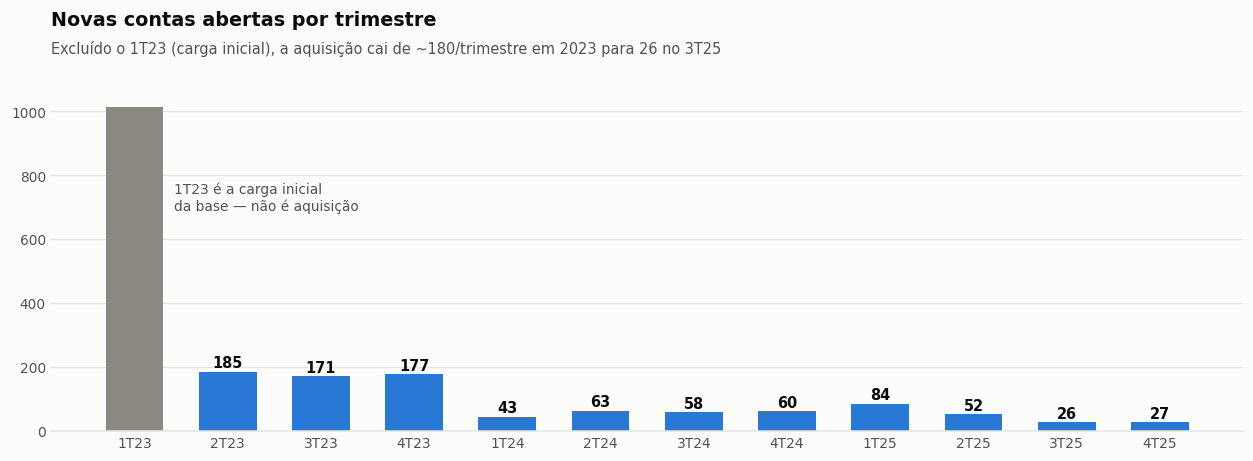

Média trimestral 2023 (2T-4T): 178 contas
Média trimestral 2024        : 56 contas
Média trimestral 2025        : 47 contas
2S25 vs 2023                 : -85%


In [13]:
# =============================================================================
# 3.2 Aquisição de clientes — a curva que já contava a história
# =============================================================================
novos = clientes.groupby(clientes.dt_conta.dt.to_period('Q')).size()

fig, ax = plt.subplots(figsize=(11.5, 4.3))
x = np.arange(len(novos))
cores = [INK3 if p == pd.Period('2023Q1') else BLUE for p in novos.index]
ax.bar(x, novos.values, width=0.62, color=cores)
ax.set_xticks(x, [rot_trim(p) for p in novos.index])
ax.annotate('1T23 é a carga inicial\nda base — não é aquisição',
            (x[0], novos.values[0]*0.72), xytext=(26, 0), textcoords='offset points',
            fontsize=9, color=INK2, va='center')
for xi, v, p in zip(x, novos.values, novos.index):
    if p != pd.Period('2023Q1'):
        ax.text(xi, v + 14, str(v), ha='center', fontsize=9.5, color=INK, fontweight='bold')
ax.set_ylim(0, novos.max()*1.12)
eixo(ax, 'Novas contas abertas por trimestre',
        'Excluído o 1T23 (carga inicial), a aquisição cai de ~180/trimestre em 2023 para 26 no 3T25')
plt.tight_layout(); plt.show()

pos = novos[novos.index > pd.Period('2023Q1')]
print(f'Média trimestral 2023 (2T-4T): {pos[pos.index.year==2023].mean():.0f} contas')
print(f'Média trimestral 2024        : {pos[pos.index.year==2024].mean():.0f} contas')
print(f'Média trimestral 2025        : {pos[pos.index.year==2025].mean():.0f} contas')
print(f'2S25 vs 2023                 : {100*(pos[pos.index>=pd.Period("2025Q3")].mean()/pos[pos.index.year==2023].mean()-1):+.0f}%')

**A aquisição já estava travada muito antes da queda de share.** Descontando o 1T23 (carga inicial da
base), o banco abria ~178 contas por trimestre em 2023, caiu para ~56 em 2024 e chegou a **26 e 27
contas** no 3T25 e 4T25 — uma queda de **85%**.

Isso é coerente com o benchmarking: os concorrentes que ganharam share (LuminaPay, Aurora) são
**nativos digitais com abertura de conta 100% digital**. O Priceless Bank não está perdendo apenas
volume dos clientes atuais — ele parou de entrar clientes novos.

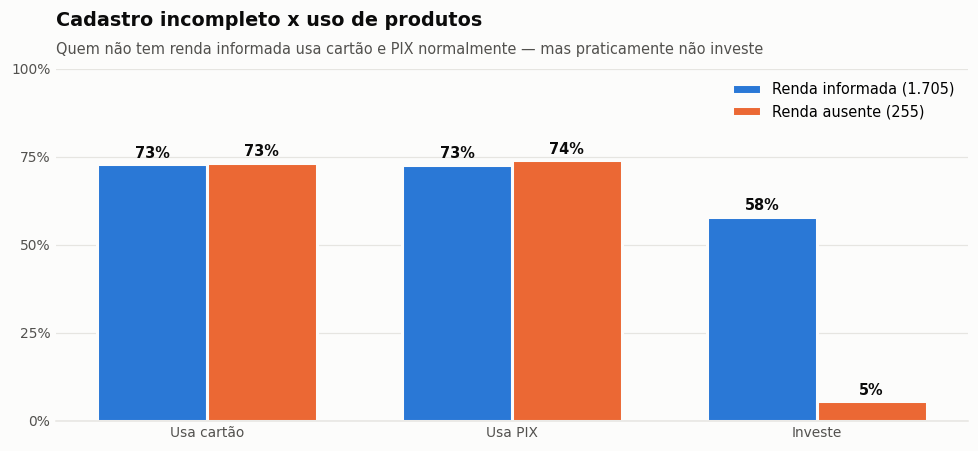

,Usa cartão %,Usa PIX %,Investe %
Renda informada (1.705),73.00,72.80,58.00
Renda ausente (255),73.30,74.10,5.50


In [14]:
# =============================================================================
# 3.3 Cadastro incompleto: os 255 clientes sem renda informada
# =============================================================================
clientes['tem_tx']  = clientes.Cliente_ID.isin(transac.Cliente_ID)
clientes['tem_pix'] = clientes.Cliente_ID.isin(pix.Cliente_ID)
clientes['tem_inv'] = clientes.Cliente_ID.isin(invest.Cliente_ID)
clientes['renda_ausente'] = clientes.Renda_Anual.isna()

comp = (clientes.groupby('renda_ausente')[['tem_tx','tem_pix','tem_inv']].mean() * 100)
comp.index = ['Renda informada (1.705)', 'Renda ausente (255)']

fig, ax = plt.subplots(figsize=(9, 4.2))
larg, xs = 0.36, np.arange(3)
ax.bar(xs - larg/2, comp.iloc[0], larg, color=BLUE,   label=comp.index[0], edgecolor=SURF, linewidth=2)
ax.bar(xs + larg/2, comp.iloc[1], larg, color=ORANGE, label=comp.index[1], edgecolor=SURF, linewidth=2)
for i in xs:
    ax.text(i - larg/2, comp.iloc[0, i] + 1.8, f'{comp.iloc[0,i]:.0f}%', ha='center', fontsize=9.5, fontweight='bold', color=INK)
    ax.text(i + larg/2, comp.iloc[1, i] + 1.8, f'{comp.iloc[1,i]:.0f}%', ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(xs, ['Usa cartão', 'Usa PIX', 'Investe'])
ax.set_ylim(0, 100); ax.set_yticks([0,25,50,75,100], ['0%','25%','50%','75%','100%'])
ax.legend(loc='upper right')
eixo(ax, 'Cadastro incompleto x uso de produtos',
        'Quem não tem renda informada usa cartão e PIX normalmente — mas praticamente não investe')
plt.tight_layout(); plt.show()

display(comp.round(1).rename(columns={'tem_tx':'Usa cartão %','tem_pix':'Usa PIX %','tem_inv':'Investe %'}))

**Achado acionável.** Os 255 clientes sem renda cadastrada **transacionam normalmente** (73,3% usam
cartão, 74,1% usam PIX — praticamente idêntico ao restante da base), mas apenas **5,5% investem**,
contra **58,0%** de quem tem renda informada. Uma diferença de **10 vezes**.

A leitura mais provável é regulatória e operacional: sem renda declarada não há *suitability*, e sem
suitability o cliente não é elegível a oferta de investimento. Ou seja, **um campo de cadastro em
branco está bloqueando a venda cruzada do produto mais estratégico do banco** — justamente o terreno
onde o Aurora Bank ganhou share (6% → 14%) com "investimento convertido em limite".

São 255 clientes ativos e não atendidos. Completar cadastro é uma ação de custo próximo de zero.

---
## 4. Base Cartões

4.006 cartões, emitidos entre janeiro de 2023 e maio de 2025. Cinco variantes Mastercard.
Como esta base **não tem `Cliente_ID`**, o vínculo com o cliente é reconstruído pela base transacional.

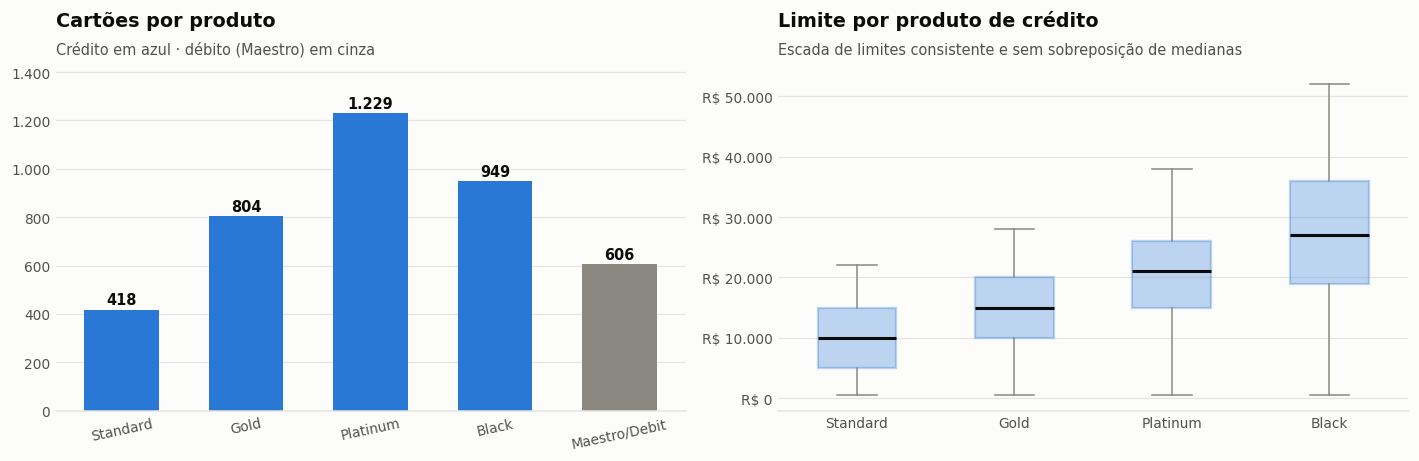

,Cartoes,Limite_mediano,Limite_medio,Limite_max,% do portfólio
Produto_Mastercard,,,,,
Standard,418,"R$ 10,000","R$ 9,761","R$ 22,000",10.4%
Gold,804,"R$ 15,000","R$ 14,261","R$ 28,000",20.1%
Platinum,"1,229","R$ 21,000","R$ 19,772","R$ 38,000",30.7%
Black,949,"R$ 27,000","R$ 26,170","R$ 52,000",23.7%
Maestro/Debit,606,R$ 0,R$ 0,R$ 0,15.1%


In [15]:
# =============================================================================
# 4.1 Portfólio de cartões
# =============================================================================
ordem = ['Standard', 'Gold', 'Platinum', 'Black', 'Maestro/Debit']
port = (cartoes.groupby('Produto_Mastercard')
        .agg(Cartoes=('ID_Cartao','size'), Limite_mediano=('Limite_Cartao','median'),
             Limite_medio=('Limite_Cartao','mean'), Limite_max=('Limite_Cartao','max'))
        .reindex(ordem))
port['% do portfólio'] = (100*port.Cartoes/port.Cartoes.sum()).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
ax.bar(range(len(port)), port.Cartoes, width=0.6,
       color=[BLUE if p != 'Maestro/Debit' else INK3 for p in port.index])
ax.set_xticks(range(len(port)), port.index, rotation=12)
for i, v in enumerate(port.Cartoes):
    ax.text(i, v+22, f'{v:,}'.replace(',', '.'), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, port.Cartoes.max()*1.15); ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Cartões por produto', 'Crédito em azul · débito (Maestro) em cinza')

ax = axes[1]
cred = cartoes[cartoes.Tipo_Cartao == 'Crédito']
dados = [cred.loc[cred.Produto_Mastercard == p, 'Limite_Cartao'].values for p in ordem[:4]]
bp = ax.boxplot(dados, widths=0.5, patch_artist=True, medianprops=dict(color=INK, lw=2),
                flierprops=dict(marker='o', ms=3, mfc=INK3, mec='none', alpha=.4),
                whiskerprops=dict(color=INK3), capprops=dict(color=INK3))
for patch, cor in zip(bp['boxes'], [BLUE]*4):
    patch.set_facecolor(cor); patch.set_alpha(.30); patch.set_edgecolor(cor); patch.set_linewidth(1.5)
ax.set_xticks(range(1, 5), ordem[:4])
ax.yaxis.set_major_formatter(FMT_BRL)
eixo(ax, 'Limite por produto de crédito', 'Escada de limites consistente e sem sobreposição de medianas')

plt.tight_layout(); plt.show()
display(port.style.format({'Cartoes':'{:,.0f}','Limite_mediano':'R$ {:,.0f}',
                           'Limite_medio':'R$ {:,.0f}','Limite_max':'R$ {:,.0f}','% do portfólio':'{:.1f}%'}))

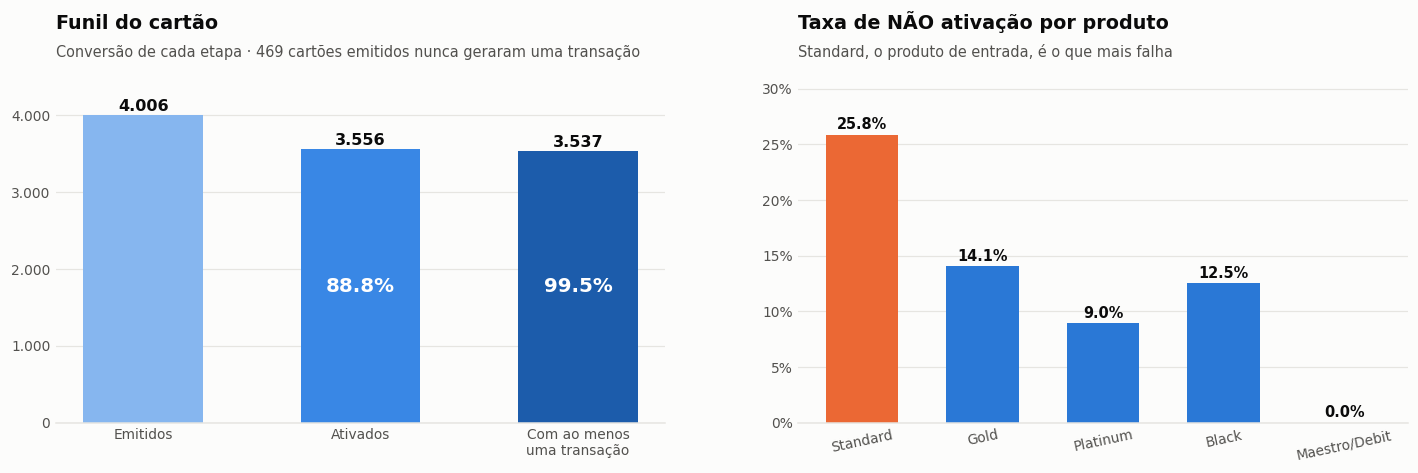

Tempo até a ativação (dias), entre os cartões ativados:
count   3,556.00
mean      131.00
std       183.00
min         0.00
25%         0.00
50%        34.00
75%       209.00
90%       421.00
max       898.00

Ativam no mesmo dia: 25.2%
Demoram mais de 6 meses: 27.6%

Cartões ativados que mesmo assim nunca transacionaram: 19


In [16]:
# =============================================================================
# 4.2 Funil: emitido -> ativado -> em uso
# =============================================================================
cartoes['ativado']  = cartoes.dt_ativacao.dt.year > 1900
cartoes['com_uso']  = cartoes.ID_Cartao.isin(transac.ID_Cartao)

n_emit = len(cartoes); n_ativ = int(cartoes.ativado.sum()); n_uso = int(cartoes.com_uso.sum())
etapas = ['Emitidos', 'Ativados', 'Com ao menos\numa transação']
vals   = [n_emit, n_ativ, n_uso]
# rampa ordinal (mesma matiz, do claro ao escuro) — nunca começar mais claro que o passo 250
ramp   = ['#86b6ef', '#3987e5', '#1c5cab']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.bar(range(3), vals, width=0.55, color=ramp)
ax.set_xticks(range(3), etapas)
for i, v in enumerate(vals):
    ax.text(i, v+55, f'{v:,}'.replace(',', '.'), ha='center', fontsize=10.5, fontweight='bold', color=INK)
    if i:
        ax.text(i, v*0.5, f'{100*v/vals[i-1]:.1f}%', ha='center', va='center',
                fontsize=13, color='white', fontweight='bold')
ax.set_ylim(0, n_emit*1.14); ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Funil do cartão',
        f'Conversão de cada etapa · {n_emit-n_uso} cartões emitidos nunca geraram uma transação')

ax = axes[1]
taxa = (100 * (1 - cartoes.groupby('Produto_Mastercard').ativado.mean())).reindex(ordem)
ax.bar(range(len(taxa)), taxa.values, width=0.6,
       color=[ORANGE if v == taxa.max() else BLUE for v in taxa.values])
ax.set_xticks(range(len(taxa)), taxa.index, rotation=12)
for i, v in enumerate(taxa.values):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, max(taxa.values)*1.22); ax.yaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'Taxa de NÃO ativação por produto', 'Standard, o produto de entrada, é o que mais falha')

plt.tight_layout(); plt.show()

ativados = cartoes[cartoes.ativado].copy()
ativados['dias_ativacao'] = (ativados.dt_ativacao - ativados.dt_emissao).dt.days
print('Tempo até a ativação (dias), entre os cartões ativados:')
print(ativados.dias_ativacao.describe(percentiles=[.25,.5,.75,.9]).round(0).to_string())
print(f'\nAtivam no mesmo dia: {100*(ativados.dias_ativacao==0).mean():.1f}%')
print(f'Demoram mais de 6 meses: {100*(ativados.dias_ativacao>180).mean():.1f}%')
print(f'\nCartões ativados que mesmo assim nunca transacionaram: {int((cartoes.ativado & ~cartoes.com_uso).sum())}')

**O funil de cartões é o vazamento mais óbvio da base.**

- **11,2% dos cartões emitidos nunca foram ativados** (450 de 4.006) — e são exatamente os mesmos 450
  cartões sem `Data_Validade`, o que confirma a leitura.
- Entre os que ativam, a mediana é de **34 dias** e o percentil 75 é de **209 dias**. Um em cada quatro
  cartões passa mais de sete meses parado antes do primeiro uso. Cada dia de atraso é receita de
  interchange que não acontece.
- O produto **Standard** — porta de entrada do banco — tem a pior taxa de não ativação (**25,8%**),
  o dobro do Platinum (9,0%). O cliente novo é justamente o que menos completa o onboarding.
- A emissão de cartões **para completamente após maio de 2025**: 26 no 1T25, 3 no 2T25, zero depois.
  Combinado com a queda de abertura de contas, indica que a máquina de aquisição parou.

Para comparação, o benchmarking mostra LuminaPay com "sem taxa de cartão" e Papaya com "cartão
adicional sem anuidade" — ambos removendo atrito exatamente nesta etapa.

---
## 5. Base Transacional

156.826 transações de cartão entre janeiro de 2023 e dezembro de 2025, de 1.431 clientes.

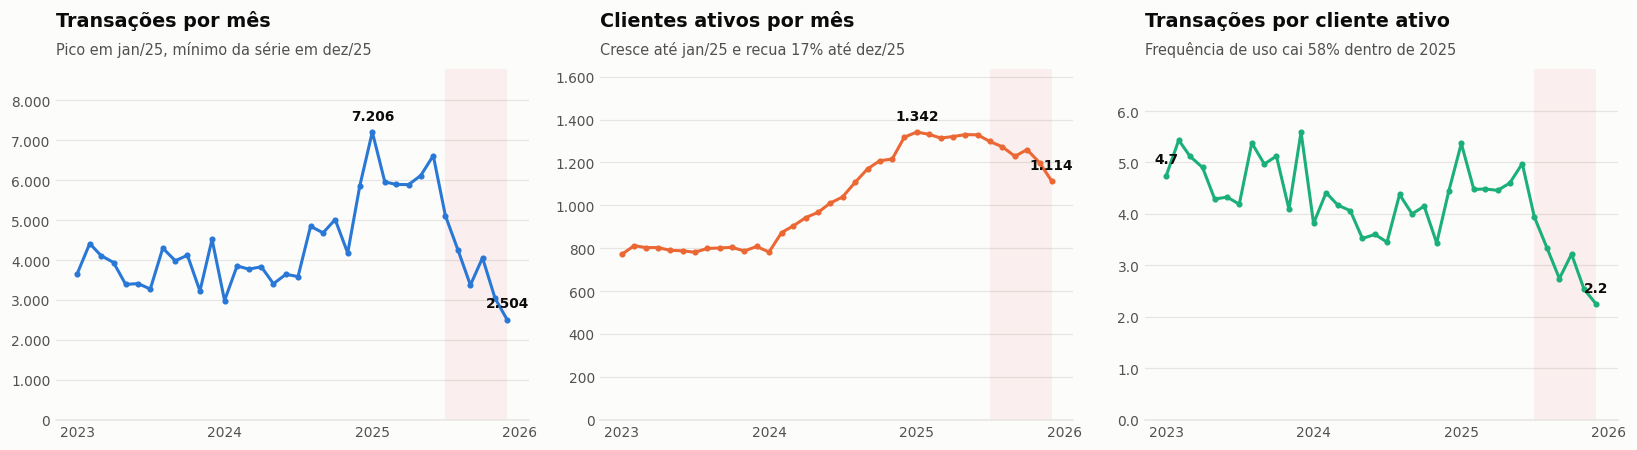

,1S25,2S25,Variação
Transações (soma),"37,678.0","22,341.0",-40.7%
Clientes ativos (soma mês a mês),"7,967.0","7,373.0",-7.5%
Frequência média,4.7,3.0,-36.4%


In [17]:
# =============================================================================
# 5.1 Evolução mensal — volume, clientes ativos e frequência
# =============================================================================
aut = transac[transac.Autorizado == 'Sim'].copy()
mensal = aut.groupby('mes').agg(transacoes=('ID_Transacao','size'),
                                clientes=('Cliente_ID','nunique'),
                                cartoes=('ID_Cartao','nunique'))
mensal['freq'] = mensal.transacoes / mensal.clientes

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
series = [('transacoes', 'Transações por mês', BLUE,  FMT_MIL, 'Pico em jan/25, mínimo da série em dez/25'),
          ('clientes',   'Clientes ativos por mês', ORANGE, FMT_MIL, 'Cresce até jan/25 e recua 17% até dez/25'),
          ('freq',       'Transações por cliente ativo', AQUA, FuncFormatter(lambda v,p: f'{v:.1f}'),
           'Frequência de uso cai 58% dentro de 2025')]
import matplotlib.dates as mdates
for ax, (col, tit, cor, fmt, sub) in zip(axes, series):
    x, y = mensal.index.to_timestamp(), mensal[col].values
    ax.plot(x, y, color=cor, marker='o', markersize=3)
    ax.axvspan(pd.Timestamp('2025-07-01'), x[-1], color=RED, alpha=0.07, lw=0)
    marcas = [0, len(y)-1] if col == 'freq' else [int(np.argmax(y)), len(y)-1]
    rotula(ax, list(x), list(y),
           fmt=(lambda v: f'{v:.1f}') if col == 'freq' else (lambda v: f'{v:,.0f}'.replace(',', '.')),
           quais=marcas, cor=INK)
    ax.yaxis.set_major_formatter(fmt); ax.set_ylim(0, max(y)*1.22)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

comp25 = pd.DataFrame({
    '1S25': [mensal.loc[mensal.index < pd.Period('2025-07'), c].loc[pd.Period('2025-01'):].sum()
             if c != 'freq' else mensal.loc[pd.Period('2025-01'):pd.Period('2025-06'), 'freq'].mean()
             for c in ['transacoes','clientes','freq']],
    '2S25': [mensal.loc[pd.Period('2025-07'):, c].sum() if c != 'freq'
             else mensal.loc[pd.Period('2025-07'):, 'freq'].mean() for c in ['transacoes','clientes','freq']],
}, index=['Transações (soma)', 'Clientes ativos (soma mês a mês)', 'Frequência média'])
comp25['Variação'] = (100*(comp25['2S25']/comp25['1S25'] - 1)).round(1).astype(str) + '%'
display(comp25.style.format({'1S25':'{:,.1f}','2S25':'{:,.1f}'}))

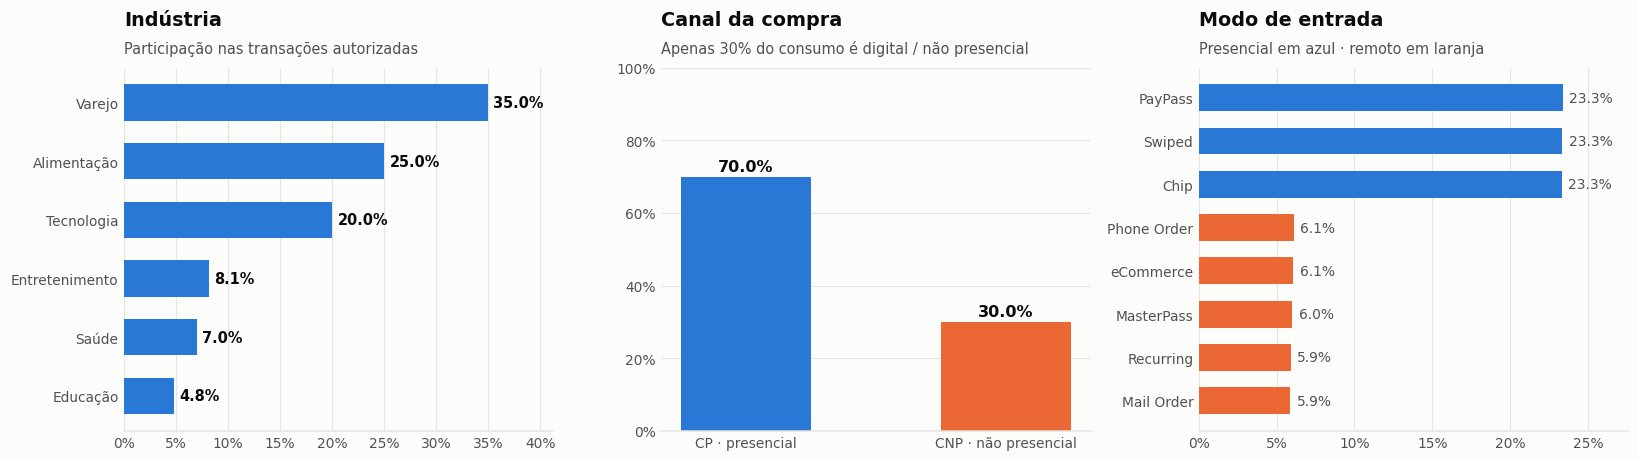

Mix de consumo por ano — nenhuma mudança relevante de comportamento:


,CNP %,Com wallet %,Parcelado %,Alimentação %,Varejo %
ano,,,,,
2023,30.20,14.10,25.30,24.90,34.90
2024,30.10,14.00,25.50,24.90,35.00
2025,29.70,14.20,25.60,25.20,35.00


In [18]:
# =============================================================================
# 5.2 Mix de consumo: indústria, canal e modo de entrada
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

ax = axes[0]
ind = aut.groupby('Industria').agg(n=('ID_Transacao','size')).sort_values('n')
ind['pct'] = 100*ind.n/ind.n.sum()
ax.barh(range(len(ind)), ind.pct, height=0.62, color=BLUE)
ax.set_yticks(range(len(ind)), ind.index)
for i, (p, n) in enumerate(zip(ind.pct, ind.n)):
    ax.text(p+0.5, i, f'{p:.1f}%', va='center', fontsize=9.5, color=INK, fontweight='bold')
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, ind.pct.max()*1.18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
eixo(ax, 'Indústria', 'Participação nas transações autorizadas')

ax = axes[1]
canal = aut.Tipo_Compra.value_counts(normalize=True).mul(100)
canal.index = ['CP · presencial' if i=='CP' else 'CNP · não presencial' for i in canal.index]
ax.bar(range(len(canal)), canal.values, width=0.5, color=[BLUE, ORANGE])
ax.set_xticks(range(len(canal)), canal.index)
for i, v in enumerate(canal.values):
    ax.text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10.5, fontweight='bold', color=INK)
ax.set_ylim(0, 100); ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
eixo(ax, 'Canal da compra', 'Apenas 30% do consumo é digital / não presencial')

ax = axes[2]
im = aut.Input_Mode.value_counts(normalize=True).mul(100).sort_values()
digitais = {'eCommerce','MasterPass','Recurring','Mail Order','Phone Order'}
ax.barh(range(len(im)), im.values, height=0.62,
        color=[ORANGE if i in digitais else BLUE for i in im.index])
ax.set_yticks(range(len(im)), im.index)
for i, v in enumerate(im.values):
    ax.text(v+0.4, i, f'{v:.1f}%', va='center', fontsize=9, color=INK2)
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, im.max()*1.18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
eixo(ax, 'Modo de entrada', 'Presencial em azul · remoto em laranja')

plt.tight_layout(); plt.show()

est = aut.assign(ano=aut.dt.dt.year)
tab = pd.DataFrame({
    'CNP %':          est.groupby('ano').apply(lambda g: 100*(g.Tipo_Compra=='CNP').mean()),
    'Com wallet %':   est.groupby('ano').apply(lambda g: 100*g.Wallet.notna().mean()),
    'Parcelado %':    est.groupby('ano').apply(lambda g: 100*(g.Qtd_Parcelas.fillna(1)>1).mean()),
    'Alimentação %':  est.groupby('ano').apply(lambda g: 100*(g.Industria=='Alimentação').mean()),
    'Varejo %':       est.groupby('ano').apply(lambda g: 100*(g.Industria=='Varejo').mean()),
}).round(1)
print('Mix de consumo por ano — nenhuma mudança relevante de comportamento:')
display(tab)

**O mix não mudou; o volume sim.** Este é um ponto importante do diagnóstico: entre 2023 e 2025 a
composição do consumo é **estável em todas as dimensões** — participação de e-commerce (30,2% → 29,7%),
uso de carteira digital (14,1% → 14,2%), parcelamento (25,3% → 25,6%), mix de indústria (variação
inferior a 1 p.p.).

Ou seja, os clientes que ficaram **não mudaram como gastam** — eles simplesmente passaram a gastar
**menos vezes**. Isso descarta a hipótese de que a queda venha de um segmento específico ou de uma
mudança de hábito de consumo, e aponta para perda de **preferência**: o cartão do Priceless Bank deixou
de ser o primeiro da carteira.

O dado do benchmarking reforça: apenas **13,6% a 42,7%** dos clientes consideram cada concorrente como
banco principal — a disputa é exatamente por essa posição.

Taxa geral de negativa: 0.53%  (839 de 156.826)


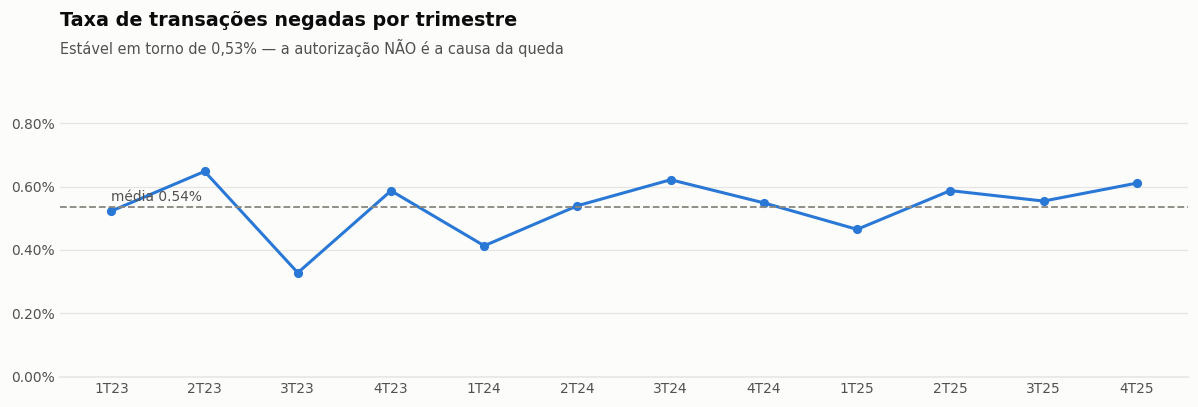


Por canal:


,Negativa %
Tipo_Compra,
CNP,0.54
CP,0.53


Por indústria:


,Negativa %
Industria,
Saúde,0.58
Alimentação,0.54
Educação,0.54
Varejo,0.54
Tecnologia,0.53
Entretenimento,0.48


In [19]:
# =============================================================================
# 5.3 Autorização e negativas
# =============================================================================
neg = transac.assign(negada=transac.Autorizado == 'Não')
print(f"Taxa geral de negativa: {100*neg.negada.mean():.2f}%  ({int(neg.negada.sum()):,} de {len(neg):,})".replace(',', '.'))

t_trim = 100*neg.groupby('trim').negada.mean()
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(t_trim))
ax.plot(x, t_trim.values, color=BLUE, marker='o')
ax.set_xticks(x, [rot_trim(p) for p in t_trim.index])
ax.axhline(t_trim.mean(), color=INK3, ls='--', lw=1.2)
ax.text(x[0], t_trim.mean()+0.02, f'média {t_trim.mean():.2f}%', fontsize=9, color=INK2)
ax.set_ylim(0, max(t_trim.values)*1.5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.2f}%'))
eixo(ax, 'Taxa de transações negadas por trimestre',
        'Estável em torno de 0,53% — a autorização NÃO é a causa da queda')
plt.tight_layout(); plt.show()

por_canal = (100*neg.groupby('Tipo_Compra').negada.mean()).round(2).to_frame('Negativa %')
por_ind   = (100*neg.groupby('Industria').negada.mean()).round(2).sort_values(ascending=False).to_frame('Negativa %')
print('\nPor canal:');     display(por_canal)
print('Por indústria:');   display(por_ind)

**Hipótese descartada.** O benchmarking cita "autorização e fraude" como um dos temas típicos da
consultoria, então vale testar: a taxa de negativa é de **0,53%** (839 de 156.826), estável em todos os 12 trimestres
(0,33% a 0,65%) e praticamente igual entre canal presencial (0,53%) e não presencial (0,54%). Não há deterioração de aprovação.

A queda de transações **não** vem de o banco estar recusando compras.

---
## 6. Base PIX

278.940 transações. É a maior base do banco — e a mais problemática (ver seções 2.3 e 2.4).

A quebra de escala do 2S25 **foi corrigida** na seção 2.6: o teste mostrou reescala pura de 4,13×, e a
coluna `Valor_norm` traz toda a série para a mesma régua. O vazio de 7 meses, esse não tem correção —
2025S1 simplesmente não existe. Então a leitura aqui é: **composição e quantidade em toda a série,
valores em R$ apenas entre semestres que existem.**

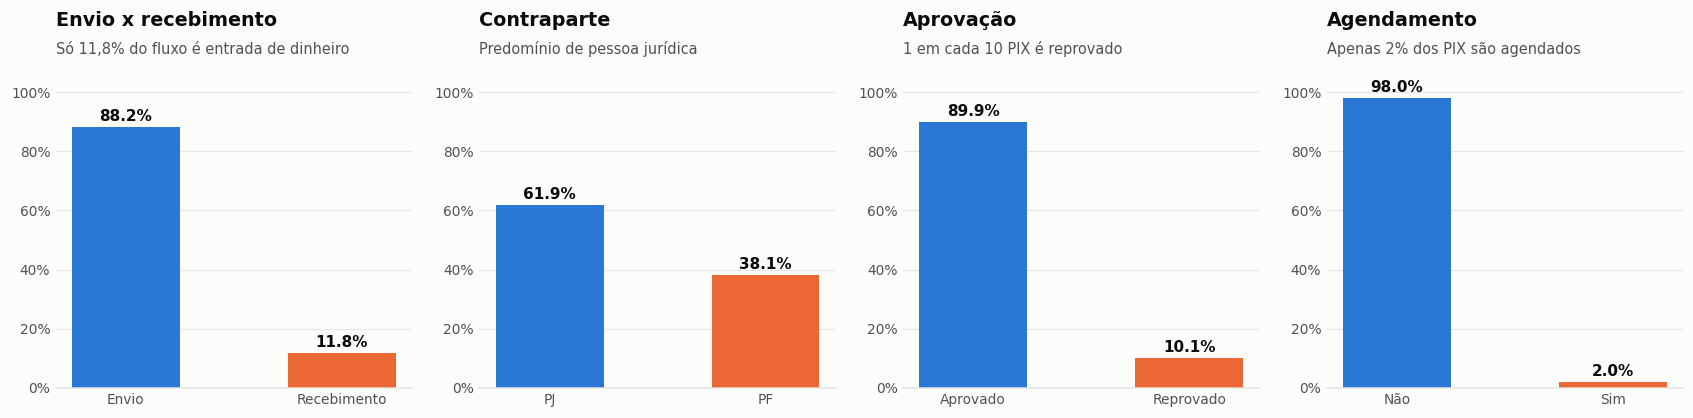

Taxa de reprovação do PIX: 10.07%

Reprovação por corte (todas praticamente idênticas — a falha é sistêmica, não de perfil):
  PF_PJ: PF=10.08% | PJ=10.06%
  Agendado: Não=10.07% | Sim=10.08%
  Tipo_transacao: Envio=10.04% | Recebimento=10.32%


In [20]:
# =============================================================================
# 6.1 Composição do PIX
# =============================================================================
pxv = pix.dropna(subset=['dt','Tipo_transacao']).copy()

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))
composicoes = [
    ('Tipo_transacao',    ['Envio','Recebimento'],  'Envio x recebimento',  'Só 11,8% do fluxo é entrada de dinheiro'),
    ('PF_PJ',             ['PJ','PF'],              'Contraparte',          'Predomínio de pessoa jurídica'),
    ('Aprovado',          [1, 0],                   'Aprovação',            '1 em cada 10 PIX é reprovado'),
    ('Agendado',          ['Não','Sim'],            'Agendamento',          'Apenas 2% dos PIX são agendados'),
]
for ax, (col, ordem_c, tit, sub) in zip(axes, composicoes):
    v = pxv[col].value_counts(normalize=True).mul(100).reindex(ordem_c)
    rot = [('Aprovado' if k==1 else 'Reprovado') if col=='Aprovado' else str(k) for k in v.index]
    ax.bar(range(len(v)), v.values, width=0.5, color=[BLUE, ORANGE][:len(v)])
    ax.set_xticks(range(len(v)), rot)
    for i, val in enumerate(v.values):
        ax.text(i, val+2, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color=INK)
    ax.set_ylim(0, 108); ax.yaxis.set_major_formatter(FuncFormatter(lambda x,p: f'{x:.0f}%'))
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

print(f"Taxa de reprovação do PIX: {100*(1-pxv.Aprovado.mean()):.2f}%")
print('\nReprovação por corte (todas praticamente idênticas — a falha é sistêmica, não de perfil):')
for c in ['PF_PJ','Agendado','Tipo_transacao']:
    print('  ' + c + ': ' + ' | '.join(f'{k}={100*(1-g.Aprovado.mean()):.2f}%' for k, g in pxv.groupby(c)))

**Uma reprovação de PIX de 10% é altíssima.** Para referência de mercado, o PIX é um arranjo com
liquidação garantida e taxas de falha típicas de operação bancária ficam bem abaixo disso.

E o padrão é revelador: **10,06% para PJ, 10,08% para PF, 10,08% agendado, 10,07% não agendado,
10,04% envio, 10,32% recebimento**. A reprovação é rigorosamente uniforme entre todos os cortes.
Isso não é comportamento de cliente (saldo insuficiente concentraria em envios de PF); é assinatura de
**falha sistêmica de plataforma** — indisponibilidade, timeout, erro de integração.

São **28.085 PIX reprovados** na série. Cada um é um cliente vendo o app do Priceless Bank falhar
naquilo que os concorrentes nativos digitais fazem sem atrito. Na tabela de benchmarking, "maturidade
digital" é exatamente o eixo em que LuminaPay (Alta) domina — e LuminaPay foi de 17% para 30% de share.

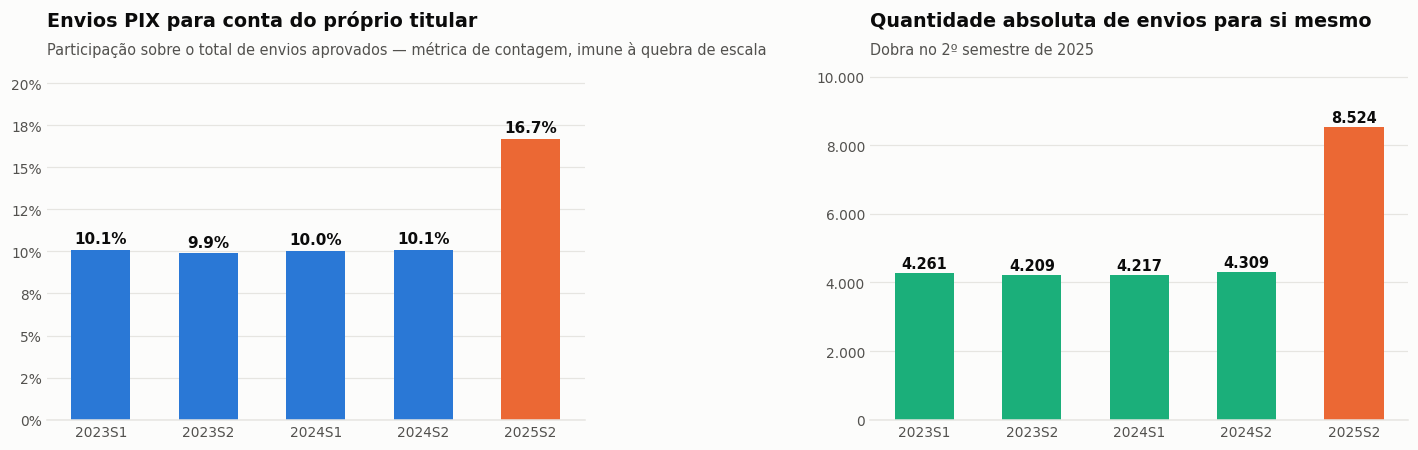

,% dos envios,Envios totais,Envios para si mesmo
semestre,,,
2023S1,10.10,42229,4261
2023S2,9.90,42563,4209
2024S1,10.00,42089,4217
2024S2,10.10,42700,4309
2025S2,16.70,51100,8524


In [21]:
# =============================================================================
# 6.2 PIX para si mesmo — o cliente movendo dinheiro para fora
# =============================================================================
env = pxv[(pxv.Tipo_transacao == 'Envio') & (pxv.Aprovado == 1)].copy()
si = env.groupby('semestre').agg(pct_si=('Pix_para_si_mesmo','mean'), n=('Pix_para_si_mesmo','size'),
                                 n_si=('Pix_para_si_mesmo','sum'))
si['pct_si'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.bar(range(len(si)), si.pct_si, width=0.55,
       color=[BLUE]*(len(si)-1) + [ORANGE])
ax.set_xticks(range(len(si)), si.index)
for i, v in enumerate(si.pct_si):
    ax.text(i, v+0.4, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color=INK)
ax.set_ylim(0, si.pct_si.max()*1.25); ax.yaxis.set_major_formatter(FuncFormatter(lambda x,p: f'{x:.0f}%'))
eixo(ax, 'Envios PIX para conta do próprio titular',
        'Participação sobre o total de envios aprovados — métrica de contagem, imune à quebra de escala')

ax = axes[1]
ax.bar(range(len(si)), si.n_si, width=0.55, color=[AQUA]*(len(si)-1) + [ORANGE])
ax.set_xticks(range(len(si)), si.index)
for i, v in enumerate(si.n_si):
    ax.text(i, v+150, f'{int(v):,}'.replace(',', '.'), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, si.n_si.max()*1.2); ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Quantidade absoluta de envios para si mesmo', 'Dobra no 2º semestre de 2025')

plt.tight_layout(); plt.show()
display(si.round(1).rename(columns={'pct_si':'% dos envios','n':'Envios totais','n_si':'Envios para si mesmo'}))

**Este é o indicador mais próximo de "o banco deixou de ser o principal".** Um PIX para conta de mesma
titularidade em outra instituição é, na prática, o cliente **transferindo o próprio dinheiro para
fora**.

A participação salta de **~10,0%** nos quatro semestres de 2023-2024 para **16,7%** no 2S25, e o número
absoluto **dobra** (de ~4.200 para 8.524). Como é métrica de contagem, ela não é afetada pela quebra de
escala descrita na seção 2.3.

**A normalização reforçou este sinal em vez de enfraquecê-lo.** A objeção natural seria: "esse salto não
é só reflexo da quebra de escala do 2S25?". Não é — e agora dá para provar. A seção 6.3 mostra que,
depois de corrigida a escala, o **ticket** do PIX fica idêntico em todos os semestres (mediana entre
R$ 152,9 e R$ 155,0). Ou seja, os clientes não passaram a mandar PIX maiores: passaram a mandar **mais
PIX**, e especificamente o dobro de PIX para si mesmos.

**Ressalva que permanece:** o 2S25 é o único semestre de 2025 com dados, então não há como saber se a
mudança começou em janeiro ou em agosto. E, estatisticamente, "a coluna foi reescalada" e "todos
multiplicaram seus PIX por 4,13" são indistinguíveis (seção 2.6). O sinal é forte e é **consistente**
com a queda de transações de cartão e o aumento de resgates no mesmo período — mas continua sendo
evidência de apoio, a ser confirmada com o banco.

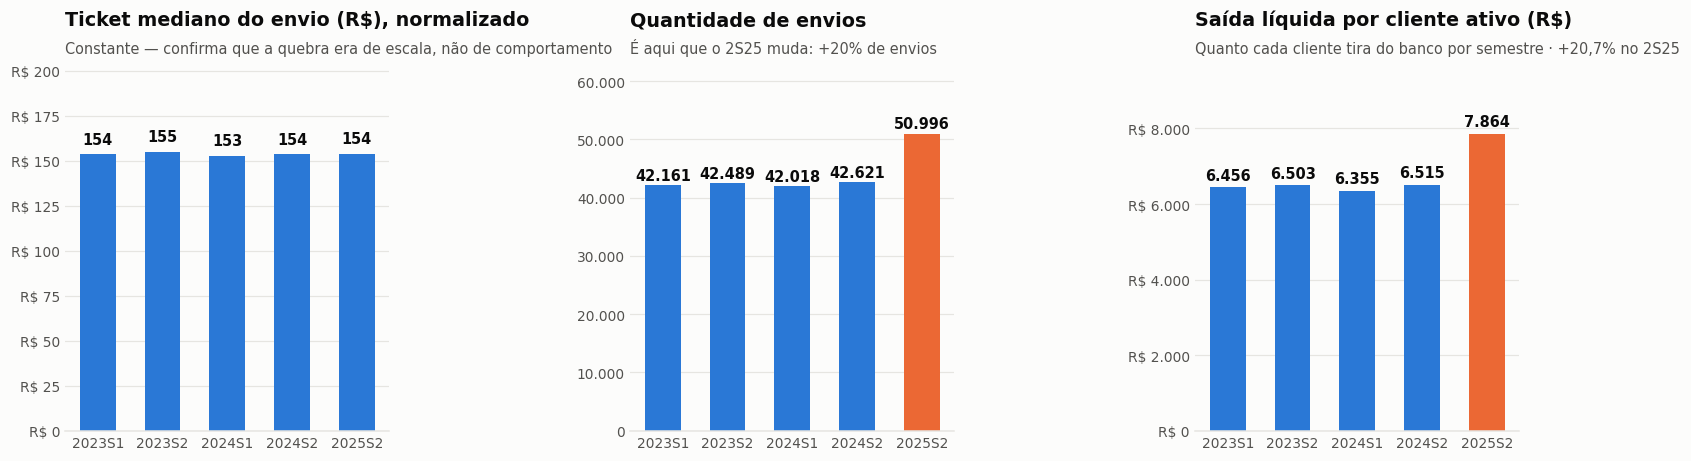

Tipo_transacao,Envio,Recebimento,Liquido,Clientes,Saida_por_cliente,Ticket_envio,Var_saida_vs_2024S2
sem,,,,,,,
2023S1,"R$ 10,713,183","R$ 1,480,797","R$ -9,232,387","1,430","R$ 6,456",R$ 153.59,-0.9%
2023S2,"R$ 10,798,400","R$ 1,499,424","R$ -9,298,975","1,430","R$ 6,503",R$ 154.96,-0.2%
2024S1,"R$ 10,590,901","R$ 1,503,552","R$ -9,087,348","1,430","R$ 6,355",R$ 152.88,-2.5%
2024S2,"R$ 10,825,822","R$ 1,509,891","R$ -9,315,931","1,430","R$ 6,515",R$ 153.59,+0.0%
2025S2,"R$ 12,830,535","R$ 1,584,893","R$ -11,245,642","1,430","R$ 7,864",R$ 154.07,+20.7%


In [22]:
# =============================================================================
# 6.3 Fluxo de caixa via PIX — agora em reais, na régua corrigida
# =============================================================================
pn = pix[(pix.Aprovado == 1) & pix.dt.notna() & pix.Valor_norm.between(0, 1e5)].copy()
pn['sem'] = pn.dt.dt.year.astype(str) + 'S' + ((pn.dt.dt.month > 6).astype(int) + 1).astype(str)

fluxo_pix = pn.pivot_table(index='sem', columns='Tipo_transacao', values='Valor_norm', aggfunc='sum')
qtd_pix   = pn.pivot_table(index='sem', columns='Tipo_transacao', values='Valor_norm', aggfunc='size')
fluxo_pix['Liquido'] = fluxo_pix.Recebimento - fluxo_pix.Envio
fluxo_pix['Clientes'] = pn.groupby('sem').Cliente_ID.nunique()
fluxo_pix['Saida_por_cliente'] = -fluxo_pix.Liquido / fluxo_pix.Clientes
fluxo_pix['Ticket_envio'] = pn[pn.Tipo_transacao == 'Envio'].groupby('sem').Valor_norm.median()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
x = np.arange(len(fluxo_pix)); dest = [BLUE]*(len(x)-1) + [ORANGE]

ax = axes[0]
ax.bar(x, fluxo_pix.Ticket_envio, width=0.55, color=BLUE)
for i, v in enumerate(fluxo_pix.Ticket_envio):
    ax.text(i, v + 6, f'{v:,.0f}'.replace(',', '.'), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, fluxo_pix.index); ax.set_ylim(0, fluxo_pix.Ticket_envio.max()*1.30)
ax.yaxis.set_major_formatter(FMT_BRL)
eixo(ax, 'Ticket mediano do envio (R$), normalizado',
        'Constante — confirma que a quebra era de escala, não de comportamento')

ax = axes[1]
ax.bar(x, qtd_pix.Envio, width=0.55, color=dest)
for i, v in enumerate(qtd_pix.Envio):
    ax.text(i, v + 900, f'{int(v):,}'.replace(',', '.'), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, qtd_pix.index); ax.set_ylim(0, qtd_pix.Envio.max()*1.22)
ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Quantidade de envios', 'É aqui que o 2S25 muda: +20% de envios')

ax = axes[2]
ax.bar(x, fluxo_pix.Saida_por_cliente, width=0.55, color=dest)
for i, v in enumerate(fluxo_pix.Saida_por_cliente):
    ax.text(i, v + 190, f'{v:,.0f}'.replace(',', '.'), ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks(x, fluxo_pix.index); ax.set_ylim(0, fluxo_pix.Saida_por_cliente.max()*1.22)
ax.yaxis.set_major_formatter(FMT_BRL)
eixo(ax, 'Saída líquida por cliente ativo (R$)', 'Quanto cada cliente tira do banco por semestre · +20,7% no 2S25')

plt.tight_layout(); plt.show()

fluxo_pix['Var_saida_vs_2024S2'] = 100*(fluxo_pix.Saida_por_cliente/fluxo_pix.Saida_por_cliente.loc['2024S2'] - 1)
display(fluxo_pix[['Envio','Recebimento','Liquido','Clientes','Saida_por_cliente','Ticket_envio','Var_saida_vs_2024S2']]
        .style.format({'Envio':'R$ {:,.0f}','Recebimento':'R$ {:,.0f}','Liquido':'R$ {:,.0f}',
                       'Clientes':'{:,.0f}','Saida_por_cliente':'R$ {:,.0f}','Ticket_envio':'R$ {:,.2f}',
                       'Var_saida_vs_2024S2':'{:+.1f}%'}))

**O PIX do Priceless Bank é uma via de mão única — e ela se acelerou.**

Com a régua corrigida, três fatos ficam visíveis:

1. **O ticket não mudou.** Mediana do envio entre R$ 152,9 e R$ 155,0 nos cinco semestres. Isso valida
   a normalização e, ao mesmo tempo, mata a hipótese de "os clientes passaram a movimentar valores
   maiores".
2. **A quantidade mudou.** Os envios sobem de ~42,4 mil para 51,0 mil (**+20%**), enquanto os
   recebimentos sobem apenas 5,6%. Entra pouco, sai muito: **88,2% das transações são saída** e, no
   2S25, para cada R$ 1,00 que entra por PIX saem R$ 8,10.
3. **Cada cliente drena mais.** A saída líquida por cliente ativo passa de ~R$ 6.500 por semestre para
   **R$ 7.864 no 2S25 (+20,7% sobre o 2S24)** — em reais comparáveis, não em reais de régua trocada.
   Os 1.430 clientes com PIX aparecem em todos os semestres, então o denominador é estável.

E um dado que fecha o quadro: **todos os 1.430 clientes que usam PIX têm fluxo líquido negativo.** Sem
exceção. Não existe no Priceless Bank um único cliente que receba mais PIX do que envia.

Combinado com o dobro de transferências para conta do próprio titular (seção 6.2), o retrato é o de um
cliente que **mantém a conta aberta e a usa como conta de passagem**: o salário entra, e é imediatamente
empurrado para outro banco. É a mesma conclusão da seção 9 — perda de *share of wallet*, não de cliente
— vista agora pelo lado do dinheiro em vez do lado do cartão.

---
## 7. Base Investimentos

21.200 operações de 1.003 clientes, entre janeiro de 2023 e dezembro de 2025.
**Esta é a única base com série completa e sem quebra de escala** — por isso é a evidência mais sólida
do diagnóstico.

In [23]:
# =============================================================================
# 7.1 O que significa Saldo_Atual? (validação empírica da semântica)
# =============================================================================
inv = invest.sort_values(['Cliente_ID','Produto_Investimento','Data']).copy()
g = inv.groupby(['Cliente_ID','Produto_Investimento'])
inv['ordem']    = g.cumcount()
inv['acum_ant'] = g.Valor_Aplicado.cumsum() - inv.Valor_Aplicado   # aportes ANTES desta linha
inv['acum_inc'] = g.Valor_Aplicado.cumsum()                        # aportes INCLUINDO esta linha

teste = pd.DataFrame([
    dict(Hipótese='Saldo_Atual = saldo APÓS o aporte da linha',
         Evidência='Saldo ≥ soma dos aportes até a linha (inclusive)',
         Aderência=f"{100*(inv.Saldo_Atual >= inv.acum_inc - 0.01).mean():.1f}%"),
    dict(Hipótese='Saldo_Atual = saldo ANTES do aporte da linha',
         Evidência='Saldo ≥ soma dos aportes anteriores (exclusive)',
         Aderência=f"{100*(inv.Saldo_Atual >= inv.acum_ant - 0.01).mean():.1f}%"),
])
display(teste.style.hide(axis='index'))

primeiras = inv[inv.ordem == 0]
resg = inv[inv.Valor_Aplicado < 0]
print(f'Primeira operação de cada par (cliente, produto) com Saldo_Atual = 0: '
      f'{100*(primeiras.Saldo_Atual == 0).mean():.1f}%')
print(f'Resgates em que |Valor_Aplicado| == Saldo_Atual exatamente (resgate total): '
      f'{int(np.isclose(-resg.Valor_Aplicado, resg.Saldo_Atual).sum())} de {len(resg)}')
print(f'Resgates maiores que o saldo exibido: {int((-resg.Valor_Aplicado > resg.Saldo_Atual + 0.01).sum())}')

d = inv[inv.ordem > 0]
print(f'\nRazão Saldo_Atual / aportes anteriores — mediana: {(d.Saldo_Atual/d.acum_ant).median():.3f} '
      '(≈ rendimento acumulado, como esperado)')

print('\nExemplo — cliente 1009, produto Reservinha:')
display(inv[(inv.Cliente_ID == 1009) & (inv.Produto_Investimento == 'Reservinha')]
        [['Data','Valor_Aplicado','Saldo_Atual','acum_ant']]
        .rename(columns={'acum_ant':'Aportes anteriores'}).style.hide(axis='index')
        .format({'Valor_Aplicado':'R$ {:,.2f}','Saldo_Atual':'R$ {:,.2f}','Aportes anteriores':'R$ {:,.2f}'}))

Hipótese,Evidência,Aderência
Saldo_Atual = saldo APÓS o aporte da linha,Saldo ≥ soma dos aportes até a linha (inclusive),46.2%
Saldo_Atual = saldo ANTES do aporte da linha,Saldo ≥ soma dos aportes anteriores (exclusive),99.9%


Primeira operação de cada par (cliente, produto) com Saldo_Atual = 0: 73.3%
Resgates em que |Valor_Aplicado| == Saldo_Atual exatamente (resgate total): 432 de 1566
Resgates maiores que o saldo exibido: 0

Razão Saldo_Atual / aportes anteriores — mediana: 1.111 (≈ rendimento acumulado, como esperado)

Exemplo — cliente 1009, produto Reservinha:


Data,Valor_Aplicado,Saldo_Atual,Aportes anteriores
202404,"R$ 1,540.65",R$ 0.00,R$ 0.00
202410,"R$ 1,512.04","R$ 1,606.50","R$ 1,540.65"
202412,"R$ 1,808.56","R$ 3,162.35","R$ 3,052.69"
202505,"R$ 1,980.87","R$ 5,147.35","R$ 4,861.25"
202506,"R$ 1,566.80","R$ 7,178.11","R$ 6,842.12"


**Conclusão sobre a semântica.** O dicionário define `Saldo_Atual` como "valor que o produto apresenta
na Data analisada", mas os dados mostram algo mais preciso — e que muda o cálculo:

1. `Saldo_Atual` é o saldo **daquele produto específico**, não da conta de investimento inteira.
   Como 745 dos 1.003 clientes têm os 4 produtos simultaneamente, o patrimônio investido do cliente é a
   **soma** das linhas dele na data.
2. `Saldo_Atual` é o saldo **de abertura** — antes da operação da linha. Três evidências convergem:
   73,3% das primeiras linhas têm saldo zero; o saldo é ≥ aportes anteriores em **100%** das linhas
   (com razão mediana de 1,11, o rendimento); e existem **432 resgates em que o valor sacado é
   exatamente igual ao saldo exibido**, sem nenhum resgate acima do saldo.
3. Por isso `Valor_Aplicado > Saldo_Atual` em 18,4% das linhas — concentrado no início do histórico
   (73% na 1ª operação, 31% na 2ª, menos de 8% da 3ª em diante). **Não é erro de dado.**

> **Fórmula correta:** saldo de fechamento do mês = `Saldo_Atual + Valor_Aplicado`.
> Patrimônio do cliente na data = soma disso sobre todos os produtos dele.

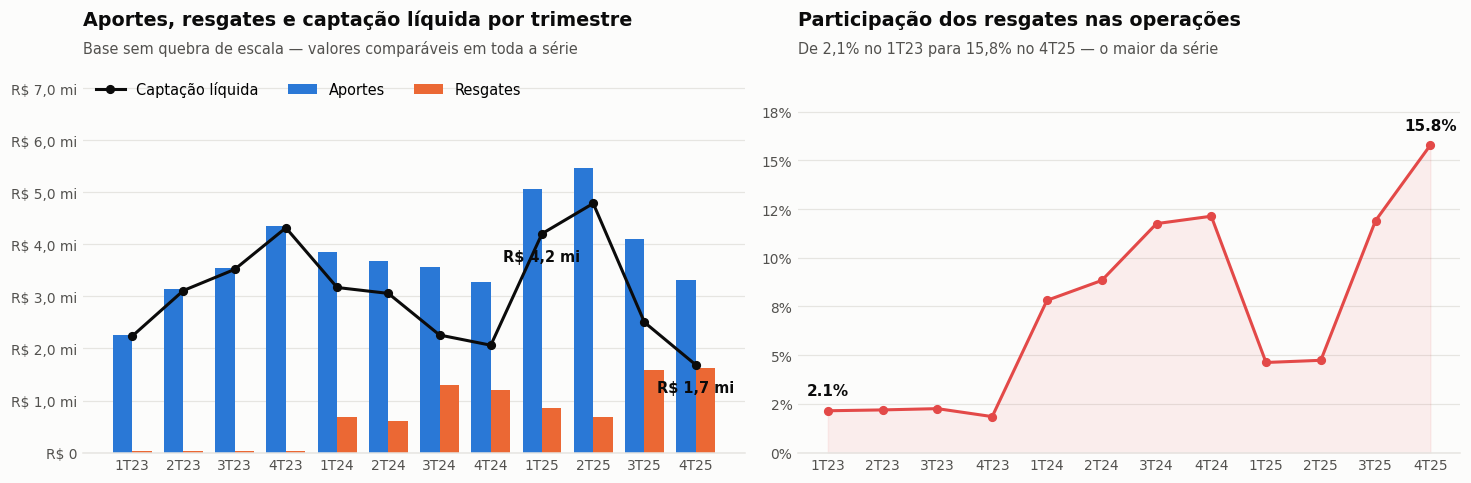

,Aportes,Resgates,Operacoes,Clientes,Liquido,Pct_resgate
trim,,,,,,
2023Q1,"R$ 2,259,732","R$ 23,814","1,070",415,"R$ 2,235,918",2.1%
2023Q2,"R$ 3,139,304","R$ 27,082","1,459",514,"R$ 3,112,221",2.2%
2023Q3,"R$ 3,542,753","R$ 25,066","1,594",584,"R$ 3,517,687",2.3%
2023Q4,"R$ 4,354,857","R$ 38,612","1,892",678,"R$ 4,316,245",1.8%
2024Q1,"R$ 3,847,442","R$ 676,761","1,766",654,"R$ 3,170,682",7.8%
2024Q2,"R$ 3,670,774","R$ 613,553","1,743",679,"R$ 3,057,221",8.8%
2024Q3,"R$ 3,560,225","R$ 1,301,915","1,770",687,"R$ 2,258,309",11.8%
2024Q4,"R$ 3,272,531","R$ 1,209,921","1,731",704,"R$ 2,062,609",12.1%
2025Q1,"R$ 5,066,088","R$ 862,309","2,118",809,"R$ 4,203,779",4.6%


In [24]:
# =============================================================================
# 7.2 Captação líquida e resgates — a evidência mais limpa da deterioração
# =============================================================================
fluxo = (invest.assign(aporte=invest.Valor_Aplicado.clip(lower=0),
                       resgate=-invest.Valor_Aplicado.clip(upper=0))
         .groupby('trim')
         .agg(Aportes=('aporte','sum'), Resgates=('resgate','sum'),
              Operacoes=('Cliente_ID','size'), Clientes=('Cliente_ID','nunique')))
fluxo['Liquido']    = fluxo.Aportes - fluxo.Resgates
fluxo['Pct_resgate'] = 100*(invest.assign(r=invest.Valor_Aplicado < 0).groupby('trim').r.mean())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax = axes[0]
x = np.arange(len(fluxo)); larg = 0.38
ax.bar(x - larg/2, fluxo.Aportes,  larg, color=BLUE,   label='Aportes')
ax.bar(x + larg/2, fluxo.Resgates, larg, color=ORANGE, label='Resgates')
ax.plot(x, fluxo.Liquido, color=INK, marker='o', lw=2, label='Captação líquida')
ax.set_xticks(x, [rot_trim(p) for p in fluxo.index])
ax.yaxis.set_major_formatter(FMT_BRL); ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, fluxo.Aportes.max()*1.35)
for i in [len(x)-4, len(x)-1]:
    ax.annotate(brl(fluxo.Liquido.iloc[i]), (x[i], fluxo.Liquido.iloc[i]), xytext=(0,-18),
                textcoords='offset points', ha='center', fontsize=9.5, fontweight='bold', color=INK)
eixo(ax, 'Aportes, resgates e captação líquida por trimestre',
        'Base sem quebra de escala — valores comparáveis em toda a série')

ax = axes[1]
ax.plot(x, fluxo.Pct_resgate, color=RED, marker='o')
ax.fill_between(x, 0, fluxo.Pct_resgate, color=RED, alpha=0.08)
ax.set_xticks(x, [rot_trim(p) for p in fluxo.index])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
ax.set_ylim(0, fluxo.Pct_resgate.max()*1.25)
for i in [0, len(x)-1]:
    ax.annotate(f'{fluxo.Pct_resgate.iloc[i]:.1f}%', (x[i], fluxo.Pct_resgate.iloc[i]), xytext=(0,10),
                textcoords='offset points', ha='center', fontsize=10, fontweight='bold', color=INK)
eixo(ax, 'Participação dos resgates nas operações',
        'De 2,1% no 1T23 para 15,8% no 4T25 — o maior da série')

plt.tight_layout(); plt.show()
display(fluxo.assign(Pct_resgate=fluxo.Pct_resgate.round(1))
        .style.format({'Aportes':'R$ {:,.0f}','Resgates':'R$ {:,.0f}','Liquido':'R$ {:,.0f}',
                       'Operacoes':'{:,.0f}','Clientes':'{:,.0f}','Pct_resgate':'{:.1f}%'}))

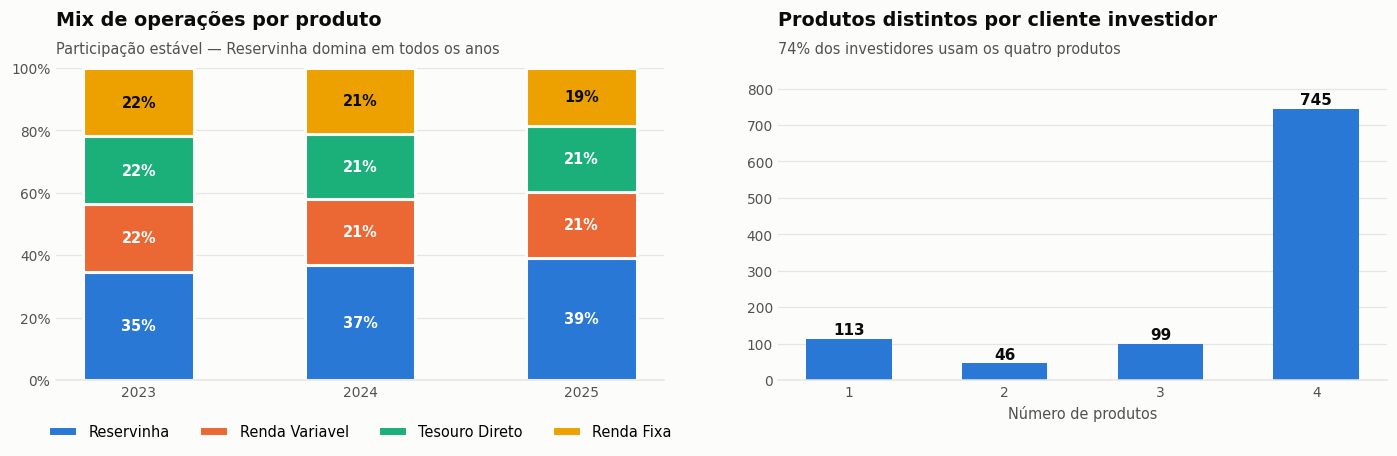

Produto_Investimento,Renda Fixa,Renda Variavel,Reservinha,Tesouro Direto
ano,,,,
2023,21.90,21.70,34.70,21.70
2024,21.20,21.30,36.80,20.70
2025,18.70,21.20,39.10,21.00


In [25]:
# =============================================================================
# 7.3 Mix de produtos de investimento
# =============================================================================
mix = invest.pivot_table(index='ano', columns='Produto_Investimento', values='Cliente_ID', aggfunc='size')
mix_pct = mix.div(mix.sum(axis=1), axis=0)*100
prods = ['Reservinha','Renda Variavel','Tesouro Direto','Renda Fixa']
cores_p = [BLUE, ORANGE, AQUA, YELLOW]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
base = np.zeros(len(mix_pct))
for p, cor in zip(prods, cores_p):
    ax.bar(range(len(mix_pct)), mix_pct[p], bottom=base, width=0.5, color=cor, label=p,
           edgecolor=SURF, linewidth=2)   # espaçador de 2px entre segmentos
    for i, (b, v) in enumerate(zip(base, mix_pct[p])):
        if v > 6:
            # texto claro sobre matiz escura, tinta escura sobre o amarelo (contraste)
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=9.5,
                    color=INK if cor == YELLOW else 'white', fontweight='bold')
    base += mix_pct[p].values
ax.set_xticks(range(len(mix_pct)), mix_pct.index)
ax.set_ylim(0, 100); ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncols=4)
eixo(ax, 'Mix de operações por produto', 'Participação estável — Reservinha domina em todos os anos')

ax = axes[1]
n_prod = invest.groupby('Cliente_ID').Produto_Investimento.nunique().value_counts().sort_index()
ax.bar(n_prod.index, n_prod.values, width=0.55, color=BLUE)
for i, v in zip(n_prod.index, n_prod.values):
    ax.text(i, v+12, f'{v}', ha='center', fontsize=10, fontweight='bold', color=INK)
ax.set_xticks([1,2,3,4]); ax.set_ylim(0, n_prod.max()*1.15)
eixo(ax, 'Produtos distintos por cliente investidor',
        f'{100*n_prod.get(4,0)/n_prod.sum():.0f}% dos investidores usam os quatro produtos',
        xlab='Número de produtos')

plt.tight_layout(); plt.show()
display(mix_pct.round(1))

**Leitura dos investimentos.**

- A **captação líquida despenca 65%** dentro de 2025: de R$ 4,78 milhões no 2T25 para R$ 1,69 milhão no
  4T25 — o pior trimestre desde o 1T23, quando a base ainda estava sendo formada.
- A **participação dos resgates** nas operações sobe de 4,7% (2T25) para **15,8% (4T25)**, o maior valor
  de toda a série de 12 trimestres. Em valor, os resgates saem de R$ 0,68 mi para R$ 1,63 mi.
- Isso acontece **na mesma janela** em que as transações de cartão caem 58% em frequência. Duas bases
  independentes, com métricas independentes, apontando na mesma direção e no mesmo momento.
- O mix de produtos é estável: a **Reservinha** (produto de liquidez, sem vencimento) concentra 37% das
  operações e é o único perpétuo. Não há produto de maior sofisticação ganhando espaço — nada
  equivalente ao "Home Broker" ou ao "investimento convertido em limite" do Aurora Bank.
- **Só 51,2% dos clientes investem**, e entre os 255 com cadastro incompleto esse número cai para 5,5%.

Como esta base não tem quebra de escala nem lacuna temporal, **é aqui que a deterioração de 2025 está
comprovada com valores em reais**, e não apenas com contagens.

---
## 8. Visão integrada — cliente 360

Aqui as cinco bases são consolidadas em uma linha por cliente. É essa tabela que permite responder
"quem é o cliente que está indo embora".

In [26]:
# =============================================================================
# 8.1 Construção da tabela cliente 360
# =============================================================================
REF = pd.Timestamp('2025-12-31')
aut = transac[transac.Autorizado == 'Sim']

c360 = clientes.set_index('Cliente_ID').copy()

# --- Cartão ---
tx_agg = aut.groupby('Cliente_ID').agg(
    tx_total=('ID_Transacao','size'), cartoes_usados=('ID_Cartao','nunique'),
    ultima_tx=('dt','max'), primeira_tx=('dt','min'))
c360 = c360.join(tx_agg)
c360['recencia_tx'] = (REF - c360.ultima_tx).dt.days
c360['tx_1s25'] = aut[aut.semestre == '2025S1'].groupby('Cliente_ID').size()
c360['tx_2s25'] = aut[aut.semestre == '2025S2'].groupby('Cliente_ID').size()
c360[['tx_1s25','tx_2s25']] = c360[['tx_1s25','tx_2s25']].fillna(0)
c360['var_semestre'] = np.where(c360.tx_1s25 > 0, c360.tx_2s25/c360.tx_1s25 - 1, np.nan)

# --- PIX (contagens + valores JÁ NORMALIZADOS na seção 2.6) ---
pxv = pix.dropna(subset=['dt','Tipo_transacao'])
c360['pix_total']     = pxv.groupby('Cliente_ID').size()
c360['pix_reprovado'] = pxv[pxv.Aprovado == 0].groupby('Cliente_ID').size()
c360['pix_para_si']   = pxv[(pxv.Tipo_transacao=='Envio') & (pxv.Pix_para_si_mesmo==1)].groupby('Cliente_ID').size()

pxa = pxv[(pxv.Aprovado == 1) & pxv.Valor_norm.between(0, 1e5)]
c360['pix_enviado']   = pxa[pxa.Tipo_transacao == 'Envio'].groupby('Cliente_ID').Valor_norm.sum()
c360['pix_recebido']  = pxa[pxa.Tipo_transacao == 'Recebimento'].groupby('Cliente_ID').Valor_norm.sum()

# --- Investimentos ---
inv_agg = invest.groupby('Cliente_ID').agg(
    inv_operacoes=('Valor_Aplicado','size'), inv_produtos=('Produto_Investimento','nunique'),
    inv_aportes=('Valor_Aplicado', lambda s: s.clip(lower=0).sum()),
    inv_resgates=('Valor_Aplicado', lambda s: -s.clip(upper=0).sum()))
c360 = c360.join(inv_agg)
c360['inv_liquido'] = c360.inv_aportes - c360.inv_resgates

# Patrimônio investido = saldo de fechamento da última operação de cada produto
ult = (invest.sort_values('Data').groupby(['Cliente_ID','Produto_Investimento']).tail(1))
c360['patrimonio_investido'] = (ult.assign(fech=ult.Saldo_Atual.fillna(0) + ult.Valor_Aplicado)
                                .groupby('Cliente_ID').fech.sum().clip(lower=0))

# --- Produto principal de cartão (maior limite entre os cartões usados) ---
dono = aut.groupby('ID_Cartao').Cliente_ID.first()
cc = cartoes.assign(cid=cartoes.ID_Cartao.map(dono)).dropna(subset=['cid'])
c360['produto_cartao'] = cc.sort_values('Limite_Cartao', ascending=False).groupby('cid').Produto_Mastercard.first()
c360['limite_total']   = cc.groupby('cid').Limite_Cartao.sum()

# --- Flags ---
for col in ['tx_total','pix_total','pix_reprovado','pix_para_si','pix_enviado','pix_recebido',
            'inv_operacoes','inv_aportes','inv_resgates','inv_liquido','patrimonio_investido','limite_total']:
    c360[col] = c360[col].fillna(0)
c360['pix_liquido'] = c360.pix_recebido - c360.pix_enviado   # negativo = dinheiro saindo do banco
c360['usa_cartao'] = c360.tx_total > 0
c360['usa_pix']    = c360.pix_total > 0
c360['investe']    = c360.inv_operacoes > 0
c360['n_frentes']  = c360[['usa_cartao','usa_pix','investe']].sum(axis=1)

print(f'Tabela cliente 360 construída: {c360.shape[0]:,} clientes × {c360.shape[1]} atributos'.replace(',', '.'))
display(c360[['idade','Renda_Anual','produto_cartao','tx_total','pix_total','pix_liquido',
              'inv_operacoes','patrimonio_investido','n_frentes','recencia_tx']].head(8))

print(f'\nClientes com PIX líquido negativo (mandam mais do que recebem): '
      f'{int((c360.pix_liquido < 0).sum())} de {int(c360.usa_pix.sum() if "usa_pix" in c360 else (c360.pix_total>0).sum())} que usam PIX')

Tabela cliente 360 construída: 1.960 clientes × 42 atributos


,idade,Renda_Anual,produto_cartao,tx_total,pix_total,pix_liquido,inv_operacoes,patrimonio_investido,n_frentes,recencia_tx
Cliente_ID,,,,,,,,,,
8528,42.00,"36,900.00",Platinum,151.00,269.00,"-23,355.27",0.00,0.00,2,5.00
3136,35.00,"38,500.00",Platinum,142.00,282.00,"-28,456.81",17.00,"2,516.88",3,2.00
5131,62.00,"115,700.00",Platinum,53.00,243.00,"-69,596.56",22.00,"67,480.56",3,1.00
5733,63.00,"109,200.00",Platinum,80.00,0.00,0.00,23.00,"104,952.15",2,11.00
2602,48.00,"74,500.00",Black,128.00,100.00,"-18,413.97",0.00,0.00,2,2.00
6483,53.00,"31,700.00",Platinum,117.00,93.00,"-6,569.51",23.00,"32,045.81",3,2.00
2457,75.00,"64,700.00",Maestro/Debit,69.00,0.00,0.00,18.00,"38,544.91",2,6.00
7448,68.00,"63,800.00",NaN,0.00,0.00,0.00,0.00,0.00,0,NaN



Clientes com PIX líquido negativo (mandam mais do que recebem): 1430 de 1430 que usam PIX


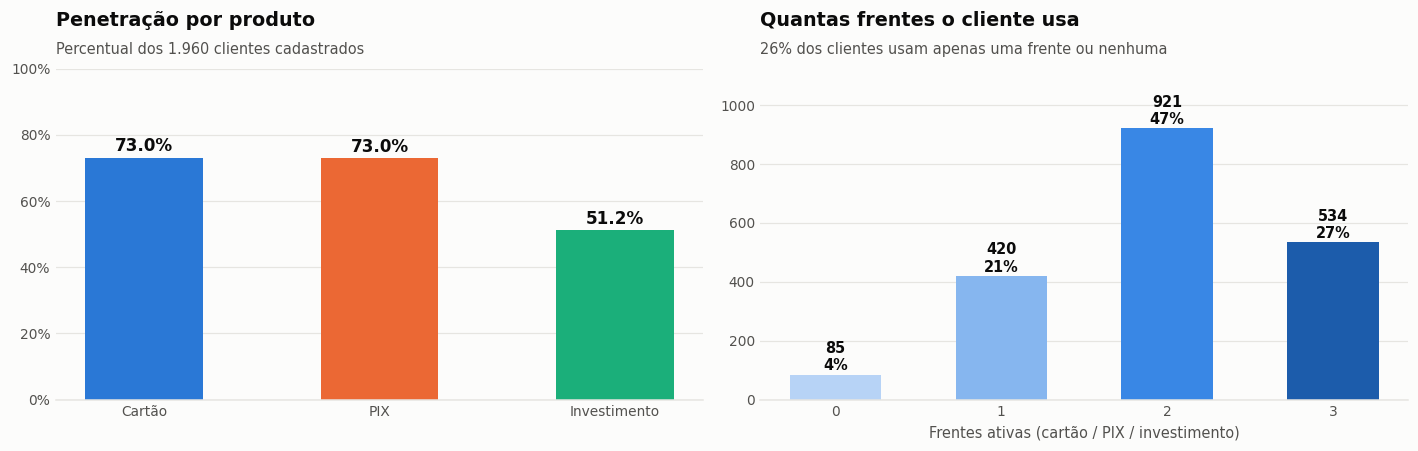

Distribuição:
  0 frente(s):   85 clientes ( 4.3%)
  1 frente(s):  420 clientes (21.4%)
  2 frente(s):  921 clientes (47.0%)
  3 frente(s):  534 clientes (27.2%)

Clientes com ZERO movimentação em 3 anos: 85
Cross-sell cartão -> investimento: dos 1431 que usam cartão, 736 investem (51.4%)


In [27]:
# =============================================================================
# 8.2 Penetração de produtos
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
pen = (c360[['usa_cartao','usa_pix','investe']].mean()*100)
pen.index = ['Cartão','PIX','Investimento']
ax.bar(range(3), pen.values, width=0.5, color=[BLUE, ORANGE, AQUA])
ax.set_xticks(range(3), pen.index)
for i, v in enumerate(pen.values):
    ax.text(i, v+2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_ylim(0, 100); ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
eixo(ax, 'Penetração por produto', 'Percentual dos 1.960 clientes cadastrados')

ax = axes[1]
nf = c360.n_frentes.value_counts().sort_index()
ramp = ['#b7d3f6', '#86b6ef', '#3987e5', '#1c5cab']
ax.bar(nf.index, nf.values, width=0.55, color=ramp)
for i, v in zip(nf.index, nf.values):
    ax.text(i, v+14, f'{v}\n{100*v/nf.sum():.0f}%', ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.set_xticks([0,1,2,3]); ax.set_ylim(0, nf.max()*1.22)
eixo(ax, 'Quantas frentes o cliente usa', '26% dos clientes usam apenas uma frente ou nenhuma',
        xlab='Frentes ativas (cartão / PIX / investimento)')

plt.tight_layout(); plt.show()

print('Distribuição:')
for k, v in nf.items():
    print(f'  {k} frente(s): {v:>4} clientes ({100*v/nf.sum():>4.1f}%)')
print(f'\nClientes com ZERO movimentação em 3 anos: {int(nf.get(0,0))}')
print(f'Cross-sell cartão -> investimento: dos {int(c360.usa_cartao.sum())} que usam cartão, '
      f'{int((c360.usa_cartao & c360.investe).sum())} investem '
      f'({100*(c360.usa_cartao & c360.investe).sum()/c360.usa_cartao.sum():.1f}%)')

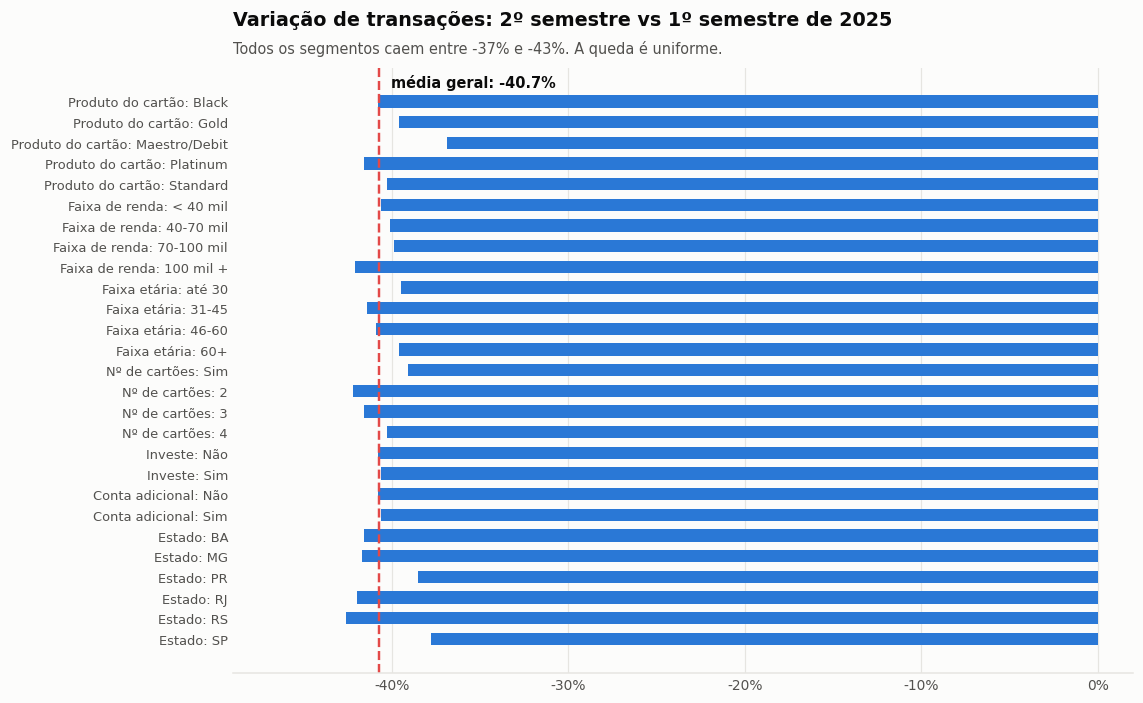

Clientes ativos no 1S25: 1.421
  · sumiram completamente no 2S25: 27
  · caíram mais de 50%: 436
  · queda mediana de frequência entre os que continuaram: -40.7%

Amplitude entre segmentos: de -42.6% a -36.9% — variação de apenas 5.7 p.p.


In [28]:
# =============================================================================
# 8.3 A queda de 2025 é geral ou concentrada em algum segmento?
# =============================================================================
ativos = c360[c360.tx_1s25 > 0]

def variacao(col, rotulo=None):
    g = ativos.groupby(col, observed=True).agg(clientes=('tx_1s25','size'),
                                               s1=('tx_1s25','sum'), s2=('tx_2s25','sum'))
    g['var_pct'] = (100*(g.s2/g.s1 - 1)).round(1)
    g.index.name = rotulo or col
    return g

cortes = [('produto_cartao','Produto do cartão'), ('faixa_renda','Faixa de renda'),
          ('faixa_etaria','Faixa etária'), ('Numero_Cartoes','Nº de cartões'),
          ('investe','Investe'), ('Possui_Conta_Adicional','Conta adicional'), ('Estado','Estado')]
BOOL_ROT = {True: 'Sim', False: 'Não'}

resultados = {rot: variacao(col, rot) for col, rot in cortes}

fig, ax = plt.subplots(figsize=(10.5, 6.5))
labels, vals = [], []
for rot, g in resultados.items():
    for idx, r in g.iterrows():
        labels.append(f'{rot}: {BOOL_ROT.get(idx, idx)}'); vals.append(r.var_pct)
y = np.arange(len(labels))[::-1]
media = 100*(ativos.tx_2s25.sum()/ativos.tx_1s25.sum() - 1)
ax.barh(y, vals, height=0.6, color=BLUE)
ax.axvline(media, color=RED, lw=1.6, ls='--')
ax.annotate(f'média geral: {media:.1f}%', xy=(media, len(labels)-0.45), xytext=(8, 0),
            textcoords='offset points', color=INK, fontsize=9.5, fontweight='bold', va='bottom')
ax.set_yticks(y, labels, fontsize=8.5)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:.0f}%'))
ax.set_xlim(min(vals)*1.15, 2)
eixo(ax, 'Variação de transações: 2º semestre vs 1º semestre de 2025',
        'Todos os segmentos caem entre -37% e -43%. A queda é uniforme.')
plt.tight_layout(); plt.show()

print(f'Clientes ativos no 1S25: {len(ativos):,}'.replace(',', '.'))
print(f'  · sumiram completamente no 2S25: {int((ativos.tx_2s25 == 0).sum())}')
print(f'  · caíram mais de 50%: {int((ativos.var_semestre < -0.5).sum())}')
print(f'  · queda mediana de frequência entre os que continuaram: '
      f'{100*ativos.loc[ativos.tx_2s25>0, "var_semestre"].median():.1f}%')
print(f'\nAmplitude entre segmentos: de {min(vals):.1f}% a {max(vals):.1f}% — '
      f'variação de apenas {max(vals)-min(vals):.1f} p.p.')

**A queda não tem dono.** Testando sete cortes diferentes — produto de cartão, renda, idade, número de
cartões, se investe, se tem conta adicional, estado — **todos caem entre -37% e -43%**, contra uma média
de -40,4%. A amplitude entre o melhor e o pior segmento é de apenas ~6 pontos percentuais.

Isso tem uma implicação estratégica direta: **não existe um segmento a defender**. Se a perda estivesse
concentrada em jovens de baixa renda, a resposta seria um produto para esse público. Como atinge
uniformemente Black e Standard, 100 mil+ e menos de 40 mil, SP e BA, a causa é **transversal** — está na
proposta de valor do banco, não em um nicho.

Note também que **só 27 clientes desapareceram** por completo entre os semestres. Não é churn em massa:
é **1.421 clientes ainda presentes, usando o banco quase metade das vezes**. O cliente não fechou a
conta — ele passou a usar o cartão do concorrente. Exatamente o que a linha "% que considera o banco
como principal" do benchmarking mede.

---
## 9. Diagnóstico consolidado — a deterioração de 2025

Quatro indicadores, de **três bases diferentes**, indexados em base 100 no 1º trimestre de 2025.
Todos são métricas de contagem ou de valor em base sem quebra de escala — comparáveis ao longo do tempo.

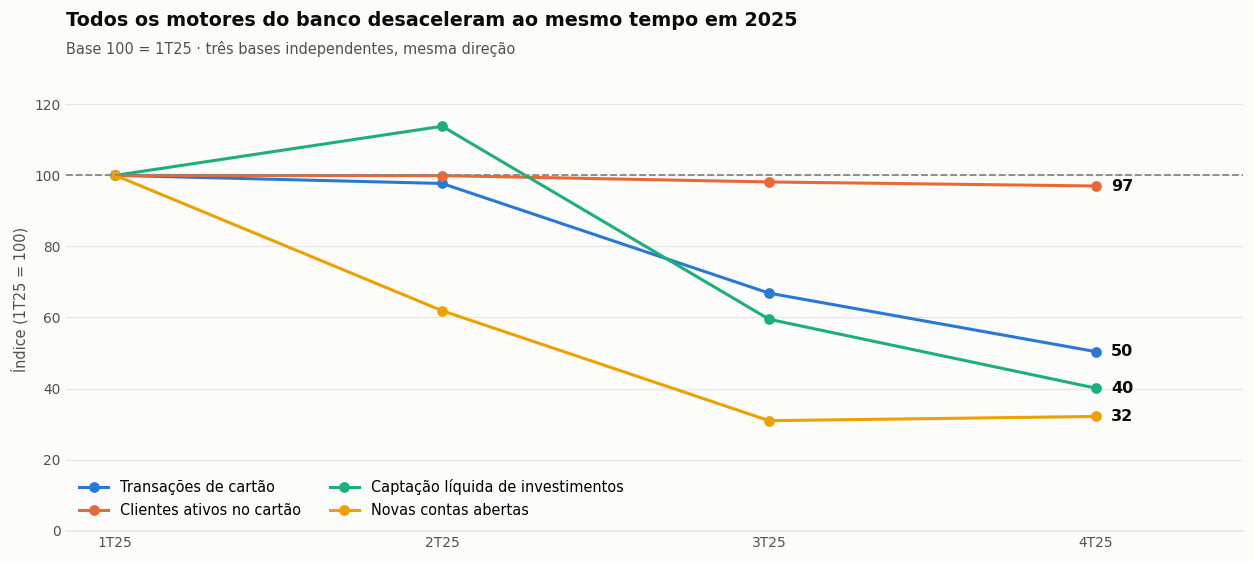

,Transações de cartão,Clientes ativos no cartão,Captação líquida de investimentos,Novas contas abertas
2025Q1,"19,056","1,403","4,203,779",84
2025Q2,"18,622","1,402","4,784,786",52
2025Q3,"12,740","1,377","2,501,523",26
2025Q4,"9,601","1,361","1,686,185",27
Variação 4T25 vs 1T25,-49.6%,-3.0%,-59.9%,-67.9%


In [29]:
# =============================================================================
# 9. Painel consolidado
# =============================================================================
trims = pd.period_range('2025Q1', '2025Q4', freq='Q')

s_tx    = aut.groupby('trim').size().reindex(trims)
s_cli   = aut.groupby('trim').Cliente_ID.nunique().reindex(trims)
s_inv   = (invest.assign(a=invest.Valor_Aplicado.clip(lower=0), r=-invest.Valor_Aplicado.clip(upper=0))
           .groupby('trim').apply(lambda g: g.a.sum()-g.r.sum()).reindex(trims))
s_novas = clientes.groupby(clientes.dt_conta.dt.to_period('Q')).size().reindex(trims).fillna(0)

painel = pd.DataFrame({'Transações de cartão': s_tx, 'Clientes ativos no cartão': s_cli,
                       'Captação líquida de investimentos': s_inv, 'Novas contas abertas': s_novas})
indexado = 100 * painel / painel.iloc[0]

fig, ax = plt.subplots(figsize=(11.5, 5.2))
cores_s = [BLUE, ORANGE, AQUA, YELLOW]
x = np.arange(len(trims))
for (nome, s), cor in zip(indexado.items(), cores_s):
    ax.plot(x, s.values, color=cor, marker='o', markersize=6, label=nome)
    ax.annotate(f'{s.values[-1]:.0f}', (x[-1], s.values[-1]), xytext=(10, 0),
                textcoords='offset points', fontsize=10.5, fontweight='bold', color=INK, va='center')
ax.axhline(100, color=INK3, lw=1.2, ls='--')
ax.set_xticks(x, [rot_trim(p) for p in trims]); ax.set_xlim(-0.15, len(trims)-0.55)
ax.set_ylim(0, 130)
ax.legend(loc='lower left', ncols=2)
eixo(ax, 'Todos os motores do banco desaceleram ao mesmo tempo em 2025',
        'Base 100 = 1T25 · três bases independentes, mesma direção', ylab='Índice (1T25 = 100)')
plt.tight_layout(); plt.show()

tabela = painel.copy()
tabela.loc['Variação 4T25 vs 1T25'] = (100*(painel.iloc[-1]/painel.iloc[0] - 1)).round(1)
display(tabela.style.format('{:,.0f}', subset=(tabela.index[:-1], tabela.columns))
        .format('{:.1f}%', subset=(tabela.index[-1:], tabela.columns)))

**O quadro fecha — e a decomposição é o achado central.** Entre o 1T25 e o 4T25:

| Indicador | 1T25 | 4T25 | Variação |
|---|---|---|---|
| Transações de cartão | 19.056 | 9.601 | **-49,6%** |
| Clientes ativos no cartão | 1.403 | 1.361 | **-3,0%** |
| Frequência (transações por cliente ativo) | 13,6 | 7,1 | **-48,1%** |
| Captação líquida de investimentos | R$ 4,20 mi | R$ 1,69 mi | **-59,9%** |
| Novas contas abertas | 84 | 27 | **-67,9%** |

Repare no contraste entre a segunda e a terceira linha. **A carteira de clientes praticamente não
mudou** — 1.403 clientes ativos no 1T25, 1.361 no 4T25, uma perda de apenas 3%. O que desabou foi
**quanto cada um usa o banco**: de 13,6 para 7,1 transações por trimestre, uma queda de 48%.

Somando as duas pontas do funil:

- **Entrada travada** — a aquisição cai 68% no ano e a emissão de cartões cessa em maio de 2025
- **Base intacta, mas parada** — o cliente não fecha a conta; ele deixa de usar
- **Dinheiro saindo** — resgates de investimento sobem de 4,7% para 15,8% das operações, e a captação
  líquida cai 60%

A queda de share de **33% para 19%** relatada no benchmarking não vem de churn: vem de o Priceless Bank
ter deixado de ser o **cartão preferido** e o **destino do dinheiro** de uma base de clientes que
continua lá. É um problema de *share of wallet*, não de retenção formal — e por isso a solução passa por
proposta de valor e engajamento, não por campanha de retenção.

---
## 10. Insights e recomendações

Cinco achados, ordenados por força da evidência e por facilidade de execução.

### Insight 1 — O banco perde uso, não clientes

**Evidência.** A carteira de clientes ativos cai só 3% em 2025 (1.403 → 1.361), mas a frequência de uso
por cliente cai 48% (13,6 → 7,1 transações/trimestre). Apenas 27 clientes desapareceram entre os
semestres, enquanto 436 caíram mais de 50% em frequência. A queda é uniforme nos 7 cortes testados
(-37% a -43%), o que descarta causa de nicho.

**Recomendação.** Tratar como problema de *share of wallet*, não de retenção. Programa de engajamento
com gatilho de frequência — o benchmarking mostra que **cashback (LuminaPay) e pontos (Papaya)** são
exatamente os mecanismos dos dois maiores ganhadores de share, e o Priceless Bank não tem equivalente.
Métrica-alvo: transações por cliente ativo por mês.

---

### Insight 2 — O funil de aquisição fechou

**Evidência.** Novas contas caem de ~178/trimestre em 2023 para 26 e 27 nos dois últimos trimestres de
2025 (-85%). A emissão de cartões vai a **zero após maio de 2025**. Além disso, 11,2% dos cartões
emitidos nunca são ativados, e a pior taxa é a do **Standard (25,8%)** — o produto de entrada.

**Recomendação.** Duas frentes: (a) reabrir aquisição por canal digital — os dois concorrentes que mais
cresceram têm abertura 100% digital, enquanto o benchmarking associa canal físico à baixa maturidade
digital; (b) atacar a ativação com onboarding assistido nos primeiros 30 dias, já que a mediana atual é
de 34 dias e o percentil 75 é de 209 dias. Cada dia parado é interchange que não acontece.

---

### Insight 3 — 1 em cada 10 PIX falha, e a falha é da plataforma

**Evidência.** 28.085 PIX reprovados (10,07%). A taxa é praticamente idêntica em todos os cortes: PF
10,08% x PJ 10,06%; agendado 10,08% x não agendado 10,07%; envio 10,04% x recebimento 10,32%. Se a causa
fosse saldo insuficiente, a reprovação se concentraria em envios de PF — não é o caso. O padrão uniforme
é assinatura de falha sistêmica, não de comportamento.

**Recomendação.** Investigação técnica de disponibilidade do arranjo PIX como prioridade um. É o ponto
de contato mais frequente do cliente com o banco (279 mil eventos contra 157 mil de cartão) e é
exatamente o eixo — maturidade digital — em que LuminaPay (Alta) saiu de 17% para 30% de share.

---

### Insight 4 — O dinheiro está saindo pelos investimentos

**Evidência.** Duas bases independentes apontam para a mesma coisa. Nos **investimentos** — base sem
quebra de escala, a evidência mais sólida do notebook — os resgates saltam de 4,7% das operações no
2T25 para **15,8% no 4T25**, o maior valor dos 12 trimestres, e a captação líquida cai 60%
(R$ 4,20 mi → R$ 1,69 mi). No **PIX**, com a escala já corrigida (seção 2.6), a saída líquida por
cliente ativo sobe **20,7%** (R$ 6.515 → R$ 7.864 por semestre) com **ticket constante** — ou seja,
mais transferências, não transferências maiores — e os envios para conta do próprio titular **dobram**
(4.309 → 8.524). Os 1.430 clientes com PIX, sem exceção, mandam mais do que recebem.

**Recomendação.** O Aurora Bank saiu de 6% para 14% de share com "Home Broker" e "investimento
convertido em limite" — mecanismos que **prendem o recurso dentro do banco**. O portfólio do Priceless
é raso: 4 produtos, com a Reservinha (liquidez imediata, sem vencimento) concentrando 37% das operações.
Vincular investimento a benefício de cartão é a alavanca com precedente comprovado no próprio
benchmarking.

---

### Insight 5 — Um campo de cadastro em branco bloqueia a venda de investimento

**Evidência.** Os 255 clientes sem `Renda_Anual` usam cartão (73,3%) e PIX (74,1%) igual ao resto da
base — mas só **5,5% investem**, contra **58,0%** de quem tem renda informada. Diferença de 10x. A
leitura provável é *suitability*: sem renda declarada, não há elegibilidade para a oferta.

**Recomendação.** Campanha de recadastramento sobre uma lista nominal de 255 clientes já ativos. É a
ação de menor custo e maior conversão esperada de toda a lista — o cliente já está no banco, já
transaciona, e só não recebe a oferta por causa de um campo vazio.

---

### Ação transversal — governança de dados

Não é insight de negócio, mas condiciona todos os outros: a base PIX tem **7 meses inteiros ausentes**,
**nenhuma chave primária** e valores negativos de até R$ -585 mil; a base de cartões **não tem
`Cliente_ID`**, o que deixa 469 cartões sem dono identificável; `Crossborder` e `Contactless` têm mais
de 82% de nulos, inutilizando justamente as métricas de maturidade digital; há duas quebras de regime
não documentadas; e o valor da compra de cartão segue uma distribuição uniforme, isto é, não reflete
consumo real. Um banco que não consegue medir o próprio funil não consegue corrigi-lo.

---
## 11. Limitações da análise

Registradas explicitamente para que as conclusões sejam usadas com o peso correto.

1. **Quebras de escala — uma corrigida, outra não.** No PIX, o teste da seção 2.6 mostrou reescala pura
   (4,13×) e os valores foram normalizados; a premissa embutida é que **a escala mudou e o
   comportamento de valor não** — estatisticamente indistinguível de "todos multiplicaram seus PIX por
   4,13", e o que decide é o contexto, não o dado. Nas transações a quebra **não é de escala**: a
   distribuição de 2024 tem outro formato, e por isso valores de cartão continuam incomparáveis entre
   anos. Antes de levar qualquer número de receita a comitê, confirmar com o banco o que mudou na
   extração em jan/2024 e em ago/2025.

2. **O valor da transação de cartão não carrega informação.** A seção 2.6 mostra que `Valor_Compra` em
   2023 e 2025 segue uma distribuição **uniforme entre R$ 0 e R$ 1.200** — formato que consumo real
   nunca tem. O campo aparenta ter sido gerado por sorteio, independentemente do cliente. Consequência:
   ticket médio, "cliente de alto valor" e gasto por faixa de renda **não são analisáveis** nesta base,
   e o "volume ajustado" da seção 2.6.3 é um proxy declarado, não receita.

3. **PIX de 2025 é parcial.** Com 2025-01 a 2025-07 ausentes, não é possível afirmar tendência de PIX no
   ano nem saber quando a mudança começou. O sinal do 2S25 entra como evidência **de apoio**.

4. **Cartão sem chave de cliente.** 469 cartões (11,7% do portfólio) não podem ser atribuídos a nenhum
   cliente, porque nunca transacionaram e a base não traz `Cliente_ID`. A análise de portfólio por
   cliente cobre 88,3% dos cartões.

5. **Renda não discrimina comportamento.** A correlação entre `Renda_Anual` e gasto em 2025 é de -0,05 e
   com número de cartões é de 0,01. Isso é consequência direta da limitação 2: se o valor da compra foi
   sorteado, ele não pode correlacionar com nada. Segmentação por poder aquisitivo fica inviável nesta
   base — o que **não** invalida as análises de contagem por faixa de renda (seção 8.3).

6. **Sem dado de concorrência no nível do cliente.** As bases mostram o que o cliente faz **dentro** do
   Priceless Bank. A hipótese de migração para concorrente é inferida (queda de frequência sem
   fechamento de conta + aumento de transferências para si mesmo), não observada. Open Finance
   resolveria isso — e o benchmarking mostra os quatro concorrentes já operando nesse eixo, com 44% a
   82% de clientes exportando informação.

7. **Janela de 3 anos, base de 1.960 clientes.** Amostra pequena para inferência estatística fina;
   suficiente para diagnóstico direcional.

---

### Sobre o tratamento das bases

Este notebook é o **diagnóstico**: ele encontra os problemas e mostra como foram encontrados. A
**remediação** vive em um arquivo separado, `tratamento.py`, que aplica 30 decisões de tratamento
documentadas e gera `bases_tratadas/` mais o relatório `TRATAMENTO.md`.

Os dois são deliberadamente separados. Se o notebook lesse as bases já limpas, o leitor veria os
números certos sem nunca ver o que estava errado — e é justamente a descoberta dos problemas que
sustenta o argumento de governança de dados da seção 10. O notebook mostra o estrago; o script
mostra o conserto.

A regra do `tratamento.py` é que **nenhuma linha é excluída**: o que não tem correção recebe uma
coluna `flag_*`, e o script aborta se qualquer base perder uma linha. Ele também documenta duas
inconsistências que este notebook não cobre — **69.427 PIX registrados antes de o cliente abrir a
conta** (24,9% da base) e **2.700 compras com cartão vencido** — ambas sinalizadas, nenhuma
corrigida, porque não há como saber qual das duas datas de cada par está errada.

In [30]:
# =============================================================================
# 12. Exportação da tabela cliente 360 e resumo executivo
# =============================================================================
cols_export = ['idade','faixa_etaria','Renda_Anual','faixa_renda','Cidade','Estado',
               'Data_Criacao_Conta','Numero_Cartoes','Possui_Conta_Adicional','produto_cartao',
               'limite_total','tx_total','cartoes_usados','tx_1s25','tx_2s25','var_semestre',
               'recencia_tx','pix_total','pix_reprovado','pix_para_si','inv_operacoes','inv_produtos',
               'pix_enviado','pix_recebido','pix_liquido',
               'inv_aportes','inv_resgates','inv_liquido','patrimonio_investido',
               'usa_cartao','usa_pix','investe','n_frentes']

export = c360[cols_export].copy()
export.to_csv('cliente_360.csv', encoding='utf-8-sig')
print(f'Arquivo cliente_360.csv gravado: {export.shape[0]:,} linhas x {export.shape[1]} colunas'.replace(',', '.'))
display(export.head(10))

linha = '=' * 78
print('\n' + linha); print('RESUMO EXECUTIVO'.center(78)); print(linha)
resumo = [
    ('Clientes cadastrados',                 f'{len(clientes):,}'.replace(',', '.')),
    ('Clientes sem nenhuma movimentacao',    f'{int((c360.n_frentes==0).sum())}'),
    ('Penetracao de investimento',           f'{100*c360.investe.mean():.1f}%'),
    ('Cartoes nunca ativados',               f'{int((~cartoes.ativado).sum())} ({100*(~cartoes.ativado).mean():.1f}%)'),
    ('Taxa de reprovacao do PIX',            f'{100*(1-pix.Aprovado.mean()):.2f}%'),
    ('Transacoes 4T25 vs 1T25',              f'{100*(s_tx.iloc[-1]/s_tx.iloc[0]-1):+.1f}%'),
    ('Clientes ativos 4T25 vs 1T25',         f'{100*(s_cli.iloc[-1]/s_cli.iloc[0]-1):+.1f}%'),
    ('Frequencia/cliente 4T25 vs 1T25',      f'{100*((s_tx.iloc[-1]/s_cli.iloc[-1])/(s_tx.iloc[0]/s_cli.iloc[0])-1):+.1f}%'),
    ('Captacao liquida 4T25 vs 1T25',        f'{100*(s_inv.iloc[-1]/s_inv.iloc[0]-1):+.1f}%'),
    ('Novas contas 4T25 vs 1T25',            f'{100*(s_novas.iloc[-1]/s_novas.iloc[0]-1):+.1f}%'),
    ('Resgates: % das operacoes no 4T25',    f'{fluxo.Pct_resgate.iloc[-1]:.1f}% (era 4,7% no 2T25)'),
    ('Saida liquida PIX/cliente 2S25 vs 2S24', f'{fluxo_pix.Var_saida_vs_2024S2.iloc[-1]:+.1f}% (escala corrigida)'),
    ('Fator de normalizacao do PIX aplicado', f'{K_PIX:.4f}x sobre 2025-08 em diante'),
]
for k, v in resumo:
    print(f'  {k:<42}{v:>32}')
print(linha)

Arquivo cliente_360.csv gravado: 1.960 linhas x 33 colunas


,idade,faixa_etaria,Renda_Anual,faixa_renda,Cidade,Estado,Data_Criacao_Conta,Numero_Cartoes,Possui_Conta_Adicional,produto_cartao,limite_total,tx_total,cartoes_usados,tx_1s25,tx_2s25,var_semestre,recencia_tx,pix_total,pix_reprovado,pix_para_si,inv_operacoes,inv_produtos,pix_enviado,pix_recebido,pix_liquido,inv_aportes,inv_resgates,inv_liquido,patrimonio_investido,usa_cartao,usa_pix,investe,n_frentes
Cliente_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8528,42.00,31-45,"36,900.00",< 40 mil,São Paulo,SP,2023-01-05,3,Não,Platinum,"80,000.00",151.00,3.00,32.00,21.00,-0.34,5.00,269.00,31.00,27.00,0.00,NaN,"26,510.44","3,155.17","-23,355.27",0.00,0.00,0.00,0.00,True,True,False,2
3136,35.00,31-45,"38,500.00",< 40 mil,Curitiba,PR,2023-01-07,2,Não,Platinum,"24,000.00",142.00,2.00,28.00,17.00,-0.39,2.00,282.00,25.00,25.00,17.00,1.00,"31,516.26","3,059.45","-28,456.81","9,696.34","24,324.22","-14,627.88","2,516.88",True,True,True,3
5131,62.00,60+,"115,700.00",100 mil +,São Paulo,SP,2023-04-23,4,Sim,Platinum,"104,000.00",53.00,4.00,29.00,18.00,-0.38,1.00,243.00,30.00,28.00,22.00,4.00,"78,224.61","8,628.05","-69,596.56","60,673.58",-0.00,"60,673.58","67,480.56",True,True,True,3
5733,63.00,60+,"109,200.00",100 mil +,São Paulo,SP,2023-01-26,3,Não,Platinum,"53,000.00",80.00,3.00,30.00,19.00,-0.37,11.00,0.00,0.00,0.00,23.00,4.00,0.00,0.00,0.00,"60,502.07","39,734.84","20,767.23","104,952.15",True,False,True,2
2602,48.00,46-60,"74,500.00",70-100 mil,Porto Alegre,RS,2023-01-18,3,Sim,Black,"74,000.00",128.00,3.00,30.00,13.00,-0.57,2.00,100.00,7.00,9.00,0.00,NaN,"21,088.08","2,674.11","-18,413.97",0.00,0.00,0.00,0.00,True,True,False,2
6483,53.00,46-60,"31,700.00",< 40 mil,Belo Horizonte,MG,2023-01-28,4,Não,Platinum,"43,000.00",117.00,4.00,28.00,21.00,-0.25,2.00,93.00,6.00,29.00,23.00,4.00,"7,878.98","1,309.47","-6,569.51","17,205.48","11,863.76","5,341.72","32,045.81",True,True,True,3
2457,75.00,60+,"64,700.00",40-70 mil,São Paulo,SP,2023-07-16,1,Não,Maestro/Debit,0.00,69.00,1.00,22.00,18.00,-0.18,6.00,0.00,0.00,0.00,18.00,4.00,0.00,0.00,0.00,"24,904.81","33,516.88","-8,612.07","38,544.91",True,False,True,2
7448,68.00,60+,"63,800.00",40-70 mil,Belo Horizonte,MG,2023-12-22,1,Não,NaN,0.00,0.00,NaN,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,False,False,0
3653,43.00,31-45,"49,600.00",40-70 mil,Salvador,BA,2023-01-11,4,Não,Black,"77,000.00",134.00,4.00,18.00,20.00,0.11,4.00,0.00,0.00,0.00,23.00,4.00,0.00,0.00,0.00,"19,351.83",-0.00,"19,351.83","22,172.76",True,False,True,2



                               RESUMO EXECUTIVO                               
  Clientes cadastrados                                                 1.960
  Clientes sem nenhuma movimentacao                                       85
  Penetracao de investimento                                           51.2%
  Cartoes nunca ativados                                         450 (11.2%)
  Taxa de reprovacao do PIX                                           10.07%
  Transacoes 4T25 vs 1T25                                             -49.6%
  Clientes ativos 4T25 vs 1T25                                         -3.0%
  Frequencia/cliente 4T25 vs 1T25                                     -48.1%
  Captacao liquida 4T25 vs 1T25                                       -59.9%
  Novas contas 4T25 vs 1T25                                           -67.9%
  Resgates: % das operacoes no 4T25                 15.8% (era 4,7% no 2T25)
  Saida liquida PIX/cliente 2S25 vs 2S24           +20.7% (escala corrigi